# Preliminary Results

## Ryan Waterman
## 8/7/2025

## Feature Engineering Plan 

Many of the existing features in the dataset lend themselves to transformation, which could improve model performance. There are six variables that have been identified as candidates for transformation, or as the basis for new features: Total_Revolving_Bal, Credit_Limit, Avg_Utilization_Ratio, Total_Trans_Amt, Months_on_book, and Total_Trans_Ct. Additional experimentation would be required, but Avg_Utilization_Ratio has a non-linear relationship with Credit_Limit and Avg_Open_To_Buy, therefore a log transformation may aid in the relevance and predictive impact of this variable. 

The ratio between Total Revolving Balance and Total Transaction Count could be added as a new feature, which would provide information about the customer’s spending habits. A high revolving balance to transaction count ratio would imply the customer is spending large amounts with few transactions, or vice versa, which may have an impact on churn rate. This variable would be called Balance_To_TC. 

Another feature that could be added is the proportion of Income Category that Credit Limit makes up. The income categories would be reduced to numerical representations, likely using a bin size adjusted mean income per income category. If customers have obtained a high credit limit relative to their income, it can be assumed they have high credit scores, for which the number of open accounts in good standing is a factor. A high number of open accounts in good standing implies the customer may be less likely to close their account. This variable would be called Credit_Limit_per_Income. 

Average Utilization Ratio, Total Transaction Amount, and Credit Limit can be compounded to identify the multiple of a given customer’s average balance is being transacted annually. Average Utilization Ratio multiplied by Credit Limit would result in the average balance carried on the card, which Total Transaction Amount could be divided by. The resulting feature would be an indication of how capable the customer is of paying their balance, normalized to their credit limit. This variable would be called Leveraged_Balance_Ratio. 

Lastly, the number of Months on Book can be multiplied by the Total Relationship Count (number of products held by the customer) to create a variable that represents the strength of the relationship the customer has with the bank. A higher value indicates a stronger relationship, as customers that are heavily invested in the products and services the bank provides may be less likely to stop utilizing the bank. This variable would be called Relationship_Strength. 

In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [151]:
data = pd.read_csv('./customer_data/customer_data.csv')

In [152]:
data.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### Step 1: Adding Features

As stated in the Feature Engineering Plan, above, several features can be added to the dataset. These features are derived from existing variables.

1. Balance_To_TC = (Total Revolving Balance) / (Total Transaction Count)

2. Credit_Limit_per_Income = (Credit Limit) / (Mean(Income Category))

3. Leveraged_Balance_Ratio = (Total Transaction Amount) / (Average Utilization Ratio * Credit Limit)

4. Relationship_Strength = Months on Book * Total Relationship Count

### Adding Balance_To_TC

In [153]:
# Add the Balance_To_TC variable
data['Balance_To_TC'] = data['Total_Revolving_Bal'] / data['Total_Trans_Ct']
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,18.500000
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,26.181818


### Adding Credit_Limit_per_Income

In [154]:
# Add the Credit_Limit_per_Income variable
# This will take some effort to remap the income category variable to a numerical value
data['Income_Category'].unique()

array(['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', 'Unknown'], dtype=object)

It appears the Income_Category variable has to be modified to properly categorize it in a numerical format. This requires a bit more exploration first.

<Axes: >

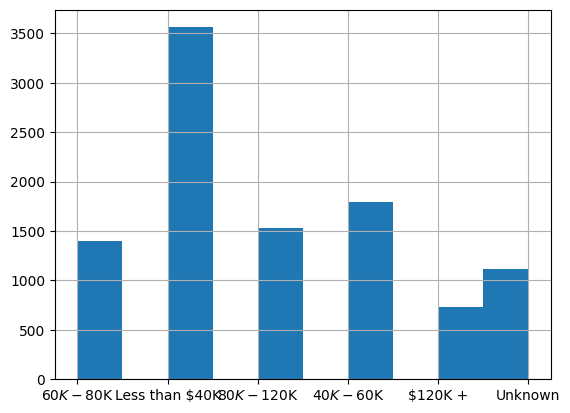

In [155]:
data['Income_Category'].hist()

In [156]:
data['Income_Category'].value_counts()

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

In [157]:
data[['Income_Category', 'Credit_Limit']].groupby(['Income_Category']).mean()

,Credit_Limit
Income_Category,
$120K +,19717.322558
$40K - $60K,5462.259832
$60K - $80K,10758.772967
$80K - $120K,15809.890945
Less than $40K,3754.404521
Unknown,9516.582464


In [158]:
data[['Income_Category', 'Credit_Limit']].groupby(['Income_Category']).std()

,Credit_Limit
Income_Category,
$120K +,12064.309210
$40K - $60K,4557.471801
$60K - $80K,8862.475017
$80K - $120K,11259.665550
Less than $40K,2759.888288
Unknown,8677.921738


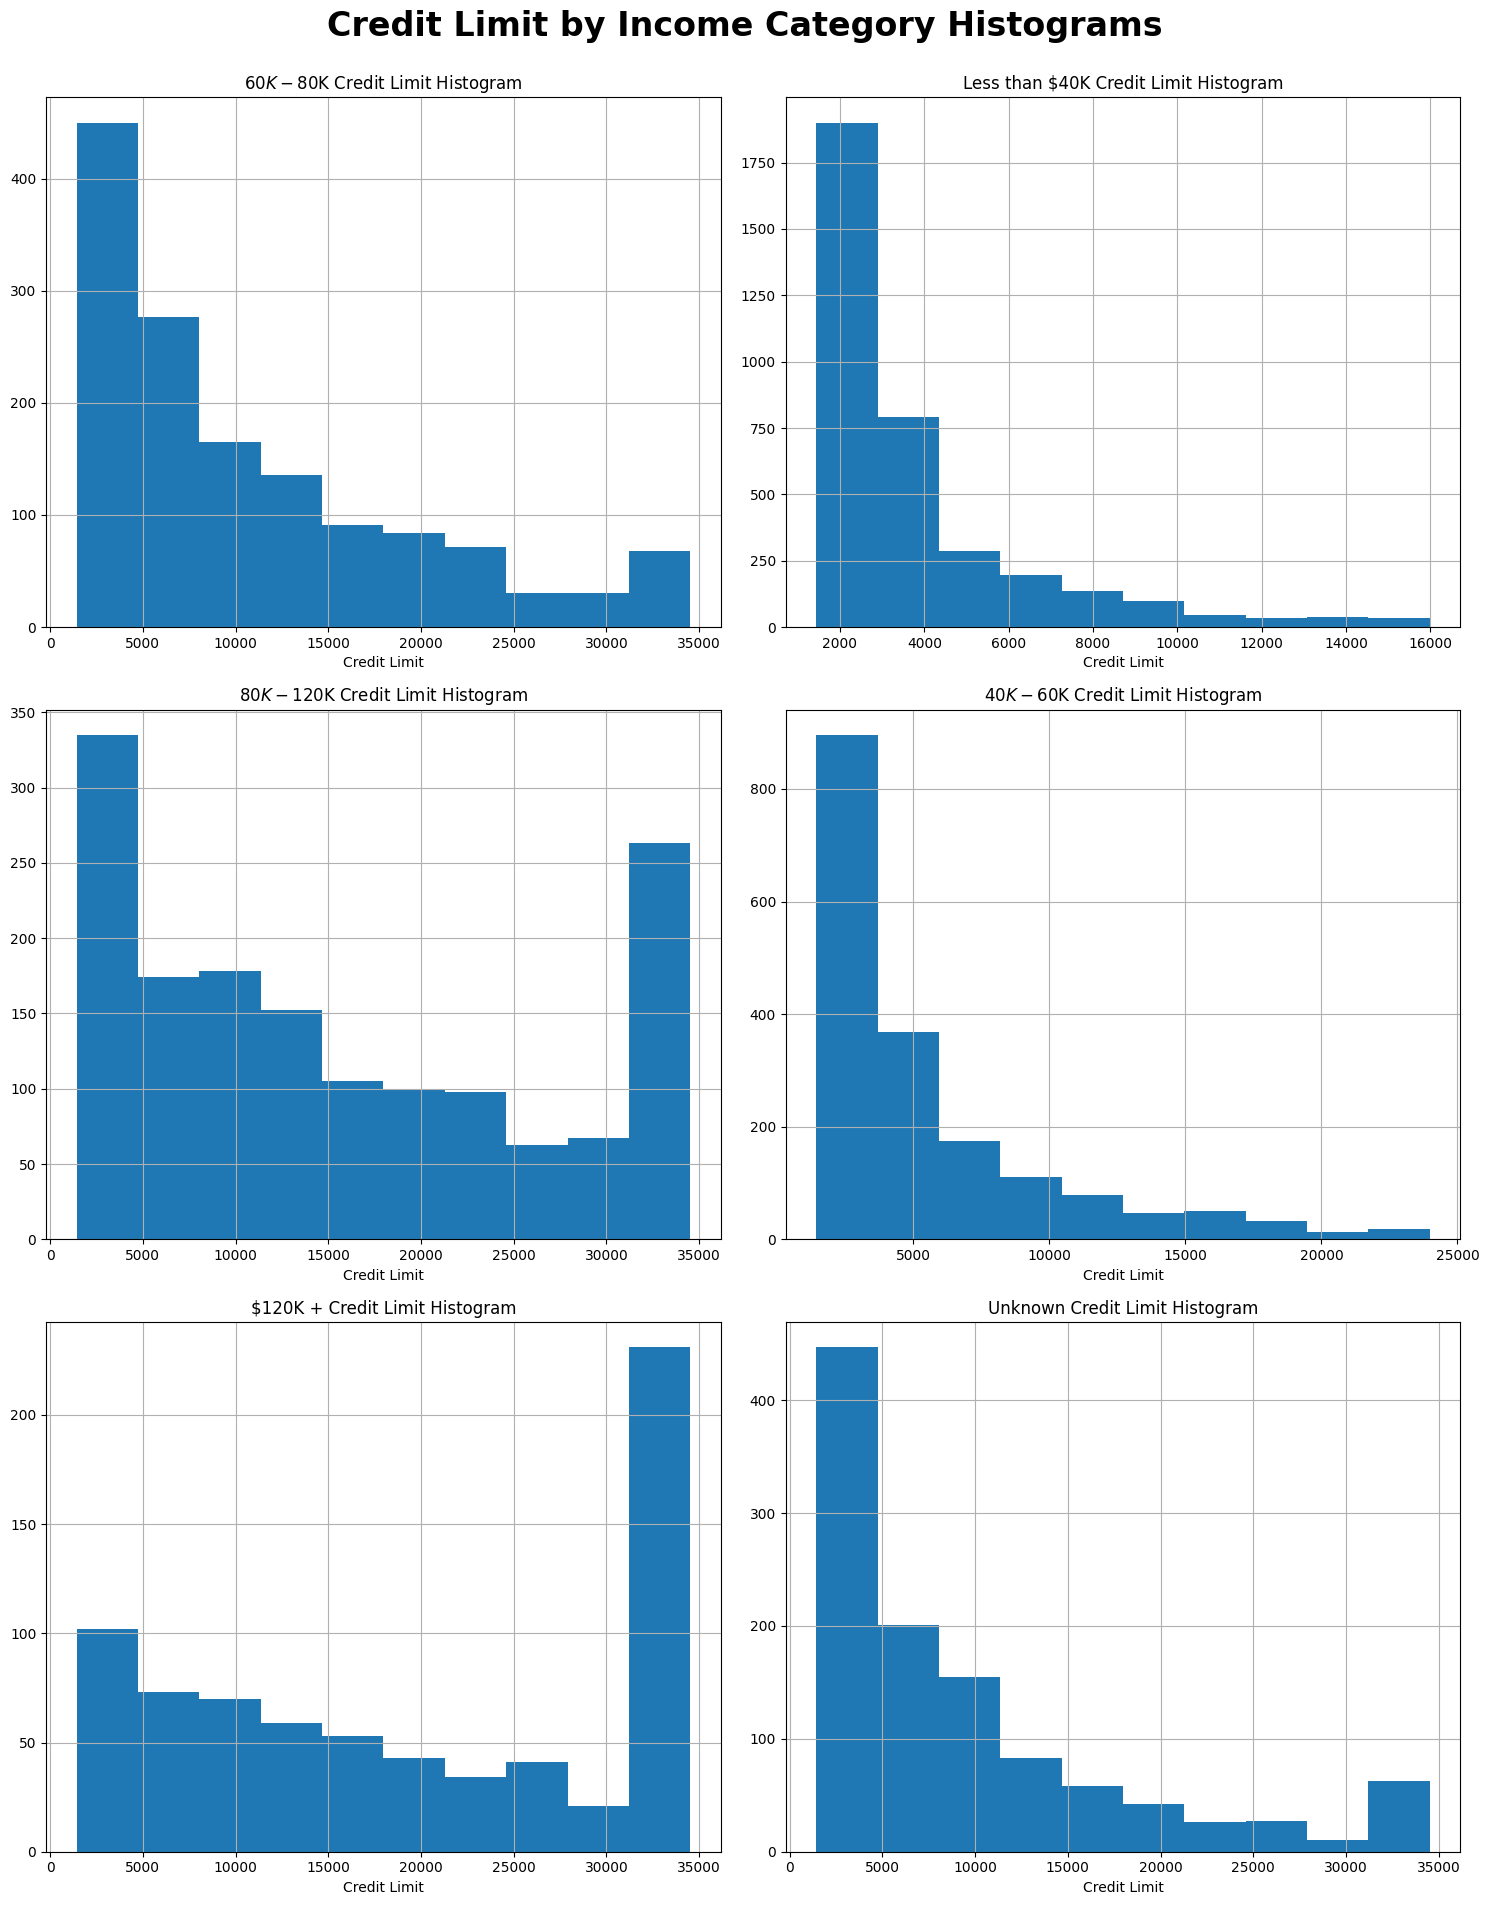

In [159]:
fig, axes = plt.subplots(3,2,figsize = (15, 20))
axes = axes.flatten()

fig.suptitle('Credit Limit by Income Category Histograms', fontsize = 24, fontweight = 'bold')

for i, cat in enumerate(data['Income_Category'].unique()):

    filtered = data[data['Income_Category']==cat]
    filtered['Credit_Limit'].hist(ax=axes[i])
    
    # Add title and axis label
    axes[i].set_title(f'{cat} Credit Limit Histogram') 
    axes[i].set_xlabel('Credit Limit') 
    
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Show the plot
plt.show()


The takeaway from these histograms is that the credit limits are non-normally distributed, so synthetic data cannot be generated based on a gaussian distrubution. Instead what I will do is create discrete income values using the proportion of credit limits for each category.

In [160]:
data['Income_Category'].replace('Less than $40K', '$0k - $40k', inplace=True)

In [161]:
income_data = {}

for cat in sorted(data['Income_Category'].unique()):
    income_data[cat] = {}

    # First filter by the current category
    filtered = data[data['Income_Category']==cat]

    bins = [bin for bin in range(0, int(max(filtered['Credit_Limit'])), int(max(filtered['Credit_Limit'])/10))]
    labels = [i for i in range(len(bins)-1)]

    # Then, bin the credit limits for the category
    binned = pd.cut(filtered['Credit_Limit'], bins=bins, labels=labels).value_counts()

    for i in range(len(binned)):
        income_data[cat] = binned

income_data      

{'$0k - $40k': Credit_Limit
 1    1728
 2     604
 0     455
 3     279
 4     177
 5     130
 6      71
 8      44
 7      36
 9      19
 Name: count, dtype: int64,
 '$120K +': Credit_Limit
 2    80
 1    78
 0    69
 3    66
 4    54
 7    46
 5    42
 6    34
 9    28
 8    27
 Name: count, dtype: int64,
 '$40K - $60K': Credit_Limit
 1    681
 0    428
 2    264
 3    144
 4     95
 6     56
 5     52
 7     35
 8     15
 9      8
 Name: count, dtype: int64,
 '$60K - $80K': Credit_Limit
 0    331
 1    315
 2    214
 3    135
 4    103
 5     88
 6     79
 7     37
 8     32
 9     19
 Name: count, dtype: int64,
 '$80K - $120K': Credit_Limit
 1    237
 0    218
 2    188
 3    172
 4    109
 5    106
 6     97
 7     75
 8     69
 9     49
 Name: count, dtype: int64,
 'Unknown': Credit_Limit
 0    322
 1    257
 2    185
 3    108
 4     62
 5     45
 6     32
 7     26
 9     22
 8     12
 Name: count, dtype: int64}

In [162]:
#Establish a delta range for each 
deltas = {
    '$0k - $40k':
        {'delta':35000,
         'base':5000},
    '$40K - $60K':
        {'delta':20000,
         'base':40000},
    '$60K - $80K':
        {'delta':20000,
         'base':60000},
    '$80K - $120K':
        {'delta':40000,
         'base':80000},
    'Unknown':
        {'delta':160000,
         'base':0},
    '$120K +':
        {'delta':40000,
         'base':120000}
          }

In [163]:
from random import randint, seed
import numpy as np

In [164]:
# Loop through the categories, identify the delta, then create the distribution based on the income_data values
numerical_incomes = {}
seed(42)
for cat in data['Income_Category'].unique():
    bins = [bin for bin in range(deltas[cat]['base'], deltas[cat]['base'] + deltas[cat]['delta'], int((deltas[cat]['delta'])/10))]

    numerical_incomes[cat] = []

    for i in range(len(bins)):
        if i < len(bins)-1:
            numerical_incomes[cat].extend([randint(bins[i], bins[i+1]) for j in range(income_data[cat].iloc[i])])
        else:
            numerical_incomes[cat].extend([randint(bins[-1], deltas[cat]['base'] + deltas[cat]['delta']) for j in range(income_data[cat].iloc[i])])

data['Numerical_Income_Category'] = np.nan

for key, val in numerical_incomes.items():
    for idx in data[data['Income_Category']==key].index:
        data['Numerical_Income_Category'].iloc[idx] = val[randint(0,len(val)-1)]


5000 40000
40000 60000
60000 80000
80000 120000
0 160000
120000 160000


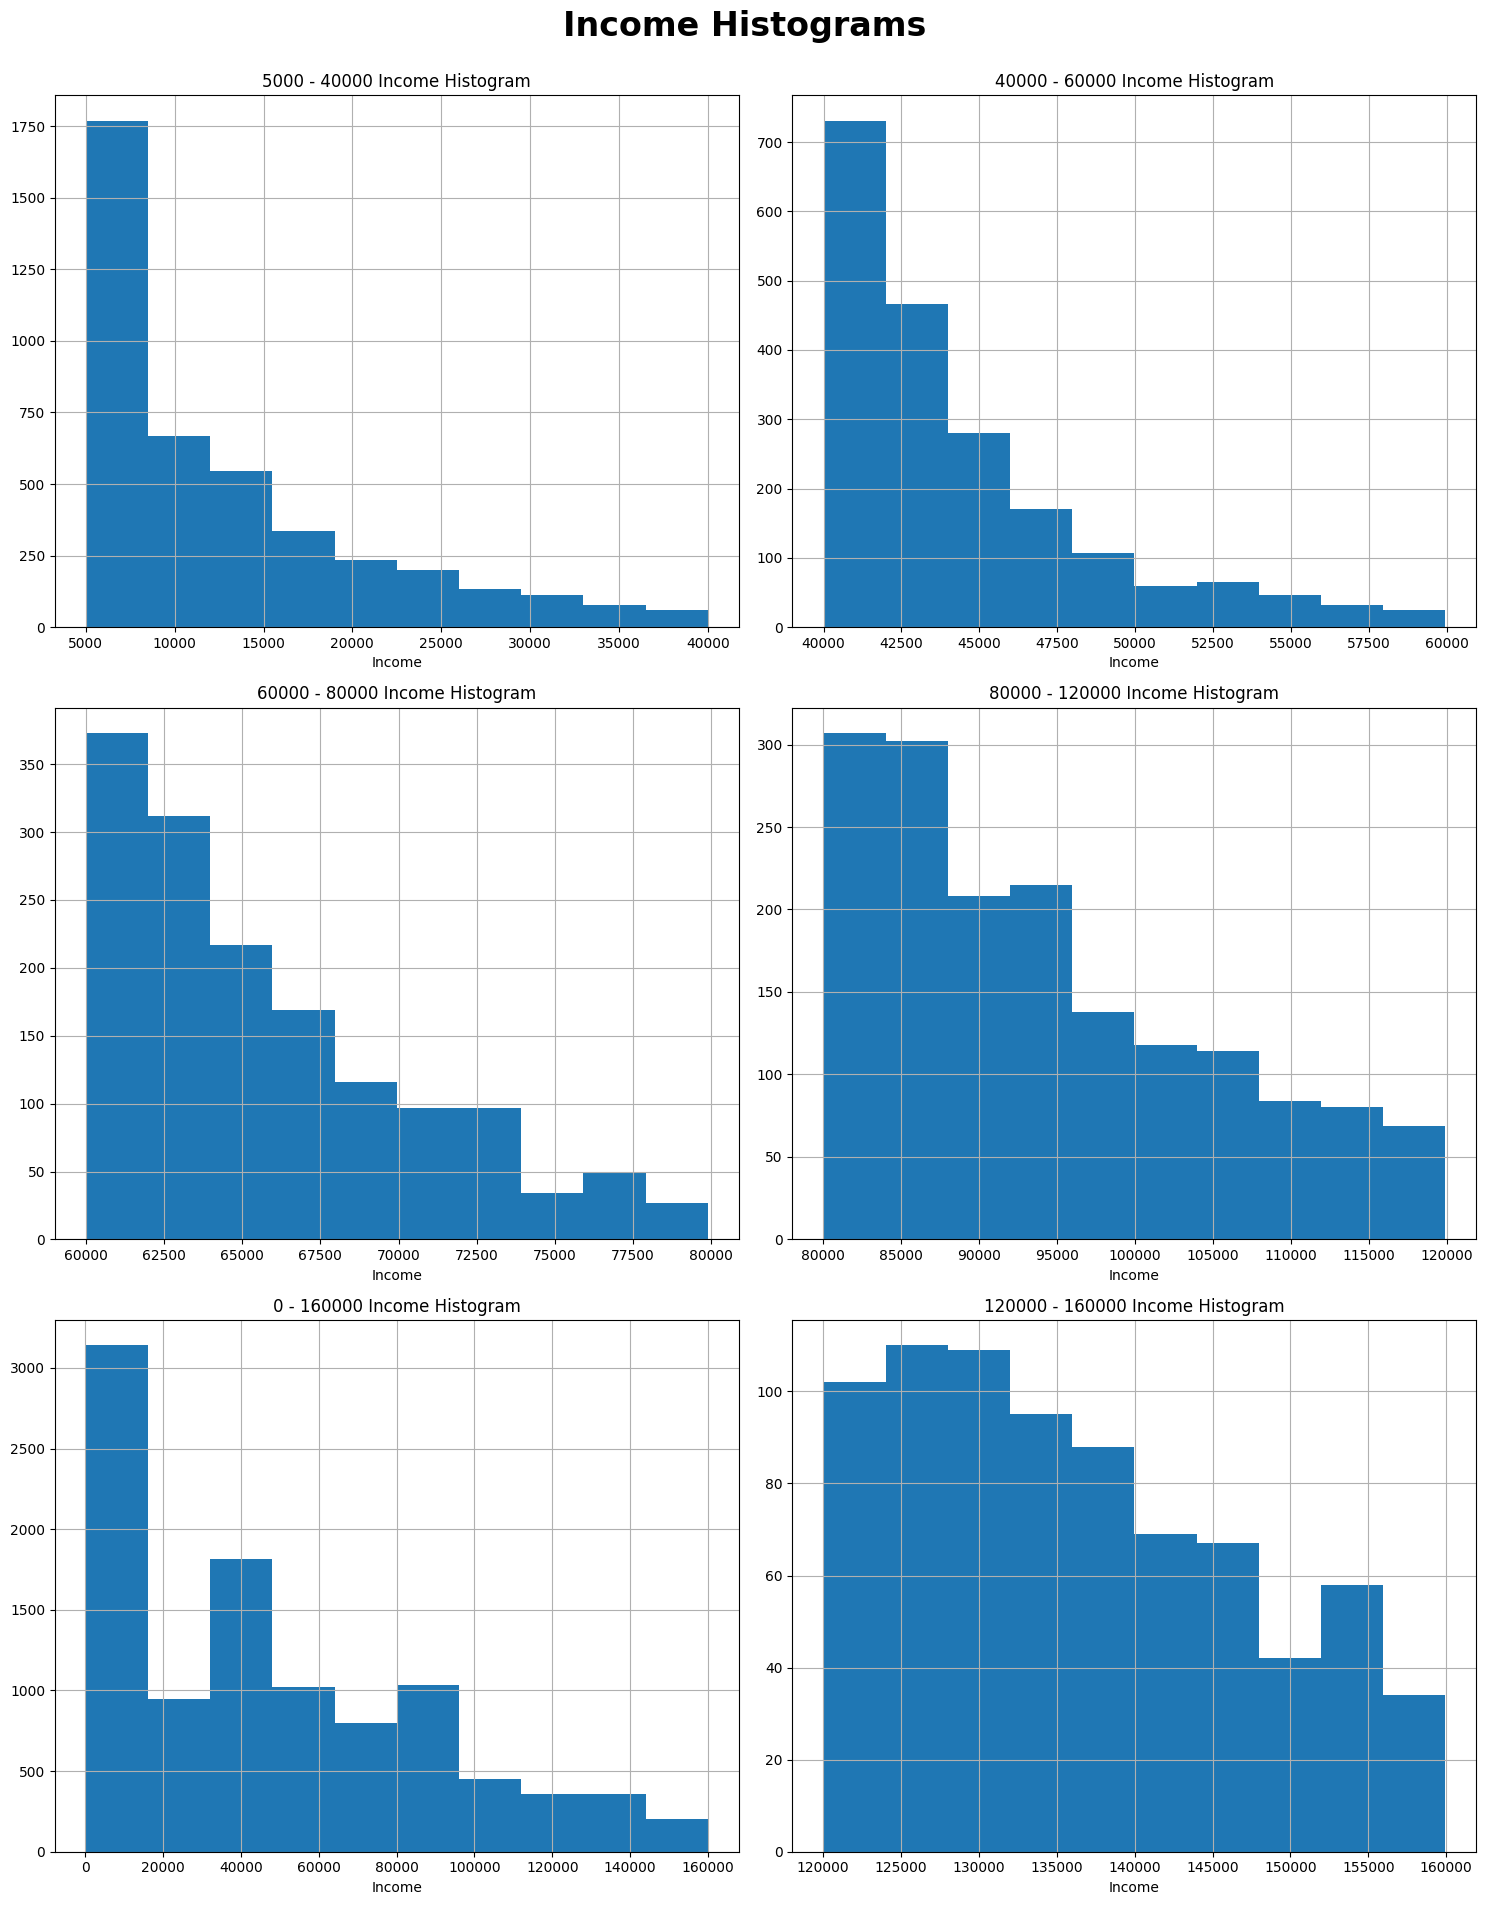

In [165]:
fig, axes = plt.subplots(3,2,figsize = (15, 20))
axes = axes.flatten()

fig.suptitle('Income Histograms', fontsize = 24, fontweight = 'bold')

for i, val in enumerate(deltas.values()):
    print(val['base'], val['base']+val['delta'])
    filtered = data[(data['Numerical_Income_Category']>=val['base']) & (data['Numerical_Income_Category']<=(val['base']+val['delta']))]
    filtered['Numerical_Income_Category'].hist(ax=axes[i])
    
    # Add title and axis label
    axes[i].set_title(f'{val['base']} - {val['base']+val['delta']} Income Histogram') 
    axes[i].set_xlabel('Income') 
    
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Show the plot
plt.show()

In [166]:
data['Income_Category'].dtype

dtype('O')

In [167]:
data['Credit_Limit_Per_Income'] = data['Credit_Limit']/data['Numerical_Income_Category']

In [168]:
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Numerical_Income_Category,Credit_Limit_Per_Income
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,18.500000,66312.0,0.191383
1,818770008,Existing Customer,49,F,5,Graduate,Single,$0k - $40k,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,26.181818,39050.0,0.211421


### Adding Leveraged_Balance_Ratio

Leveraged_Balance_Ratio = (Total Transaction Amount) / (Average Utilization Ratio * Credit Limit)

In [169]:
data['Leveraged_Balance_Ratio'] = (data['Avg_Utilization_Ratio']*data['Credit_Limit'])/data['Total_Trans_Amt']

In [170]:
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Numerical_Income_Category,Credit_Limit_Per_Income,Leveraged_Balance_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,18.500000,66312.0,0.191383,0.676705
1,818770008,Existing Customer,49,F,5,Graduate,Single,$0k - $40k,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,26.181818,39050.0,0.211421,0.671479


### Adding Relationship_Strength 

Relationship_Strength = Months on Book * Total Relationship Count

In [171]:
data['Relationship_Strength'] = data['Months_on_book']*data['Total_Relationship_Count']

In [172]:
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Numerical_Income_Category,Credit_Limit_Per_Income,Leveraged_Balance_Ratio,Relationship_Strength
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,18.500000,66312.0,0.191383,0.676705,195
1,818770008,Existing Customer,49,F,5,Graduate,Single,$0k - $40k,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,26.181818,39050.0,0.211421,0.671479,264


## Select Variables

| Variable | Type |
|-------------|-------------|
| Contacts_Count_12_mon | Quantitative| 
| Total_Revolving_Bal | Quantitative |
| Total_Amt_Chng_Q4_Q1 | Quantitative |
| Total_Trans_Amt | Quantitative |
| Total_Trans_Ct | Quantitative |
| Total_Ct_Chng_Q4_Q1 | Quantitative |
| Avg_Utilization_Ratio | Quantitative |
| Balance_To_TC | Quantitative |
| Credit_Limit_per_Income | Quantitative |
| Leveraged_Balance_Ratio | Quantitative |
| Relationship_Strength | Quantitative |
| Income_Category | Categorical |
| Gender | Categorical |
| Education_Level | Categorical| 
| Marital_Status | Categorical| 
| Card_Category | Categorical|

In [173]:
columns_to_keep = set(['Attrition_Flag', "Contacts_Count_12_mon", "Total_Revolving_Bal", "Total_Amt_Chng_Q4_Q1",
                    "Total_Trans_Amt", "Total_Trans_Ct", "Total_Ct_Chng_Q4_Q1", "Avg_Utilization_Ratio",
                    "Balance_To_TC", "Credit_Limit_per_Income", "Leveraged_Balance_Ratio", "Relationship_Strength",
                    "Income_Category", "Gender", "Education_Level", "Marital_Status", "Card_Category",
                    'Credit_Limit_Per_Income'])

columns = set(data.columns)

data.drop(list(columns-columns_to_keep), axis = 1, inplace=True)

## Convert Categorical Variables to Numerical Representations 

In [174]:
categorical_vars = ['Attrition_Flag', "Income_Category", "Gender", "Education_Level", "Marital_Status", "Card_Category"]
cat_counts = {}

for var in categorical_vars:
    cat_counts[var] = [[cat for cat in data[var].unique()], [i for i in range(len(data[var].unique()))]]

cat_counts

{'Attrition_Flag': [['Existing Customer', 'Attrited Customer'], [0, 1]],
 'Income_Category': [['$60K - $80K',
   '$0k - $40k',
   '$80K - $120K',
   '$40K - $60K',
   '$120K +',
   'Unknown'],
  [0, 1, 2, 3, 4, 5]],
 'Gender': [['M', 'F'], [0, 1]],
 'Education_Level': [['High School',
   'Graduate',
   'Uneducated',
   'Unknown',
   'College',
   'Post-Graduate',
   'Doctorate'],
  [0, 1, 2, 3, 4, 5, 6]],
 'Marital_Status': [['Married', 'Single', 'Unknown', 'Divorced'],
  [0, 1, 2, 3]],
 'Card_Category': [['Blue', 'Gold', 'Silver', 'Platinum'], [0, 1, 2, 3]]}

In [175]:
for key, val in cat_counts.items():
    data[key].replace(val[0], val[1], inplace = True)

In [176]:
data.head(5)

,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category,Contacts_Count_12_mon,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Balance_To_TC,Credit_Limit_Per_Income,Leveraged_Balance_Ratio,Relationship_Strength
0,0,0,0,0,0,0,3,777,1.335,1144,42,1.625,0.061,18.500000,0.191383,0.676705,195
1,0,1,1,1,1,0,2,864,1.541,1291,33,3.714,0.105,26.181818,0.211421,0.671479,264
2,0,0,1,0,2,0,0,0,2.594,1887,20,2.333,0.000,0.000000,0.038316,0.000000,144
3,0,1,0,2,1,0,1,2517,1.405,1171,20,2.333,0.760,125.850000,0.152941,2.150196,102
4,0,0,2,0,0,0,0,0,2.175,816,28,2.500,0.000,0.000000,0.064127,0.000000,105


## Null Models

In [177]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, roc_curve, roc_auc_score

In [178]:
class ModelEvaluator():
    def __init__(self, name):
        self.name = name
    
    def fit_model(self, X, y):
        if self.name == 'Logistic Regression':
            import statsmodels.api as sm
            self.model = sm.Logit(y, X).fit()
        elif self.name == 'LDA':
            from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
            self.model = LinearDiscriminantAnalysis().fit(X, y)
        elif self.name == 'QDA':
            from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
            self.model = QuadraticDiscriminantAnalysis().fit(X, y)
        elif self.name == 'KNN':
            from sklearn.neighbors import KNeighborsClassifier
            n_neighbors = int(input('Enter the number of neighbors:'))
            print(f'Number of neighbors selected: {n_neighbors}')
            self.model = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
        elif self.name == 'Naive Bayes':
            from sklearn.naive_bayes import CategoricalNB
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(X)
            self.model = CategoricalNB(min_categories=2).fit(X_scaled,y)

    def eval_model(self, novel_X, novel_y, labels):
        self.novel_x = novel_X
        self.novel_y = novel_y
        self.labels = labels

        if len(self.novel_x.shape)>1:
            shape = (self.novel_x.shape[0], self.novel_x.shape[1])
        else:
            shape = (-1,1)

        if self.name == 'Naive Bayes':
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(np.array(novel_X).reshape(shape[0],shape[1]))
            self.predictions = self.model.predict(X_scaled.reshape(shape[0],shape[1]))
        else:
            self.predictions = self.model.predict(np.array(novel_X).reshape(shape[0],shape[1]))

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred >= 0.5:
                self.reclassified_predictions.append(1)
            else:
                self.reclassified_predictions.append(0)

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y.values):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_accuracy()
        self._plot_cm()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        fig, axes = plt.subplots(1,2,figsize=(15,10))
        axes = axes.flatten()

        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues,ax=axes[0])

        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')


        axes[1].plot(self.fpr, self.tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {self.auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

        plt.show()

    def _compute_accuracy(self):
        # Calculate the ROC curve points
        self.fpr, self.tpr, self.thresholds = roc_curve(self.novel_y, self.predictions)

        # Calculate the AUC
        self.auc = roc_auc_score(self.novel_y, self.predictions)

        self.accuracy = accuracy_score(self.novel_y, self.reclassified_predictions)
        print(f'\nAccuracy: {self.accuracy}')

In [179]:
def split_data(data):
    seed(42)
    train_perc = 80
    train_indices = []
    eval_indices = []

    for i in data.index.values:
        rand_num = randint(1,100)
        if rand_num <= train_perc:
            train_indices.append(i)
        else:
            eval_indices.append(i)

    training_data = data.iloc[train_indices]
    eval_data = data.iloc[eval_indices]
    
    return training_data, eval_data

In [180]:
def reduce_data(data, percentage):
    seed(42)
    reduction_percentage = percentage
    remove_indices = []

    for i in data[data['Attrition_Flag']==0].index.values:
        rand_num = randint(1,100)
        if rand_num <= reduction_percentage:
            remove_indices.append(i)

    remove = set(remove_indices)
    all_indices = set(data.index.values)

    reduced_data = data.iloc[list(all_indices - remove)]
    reduced_data.reset_index(inplace=True)
    return reduced_data

## Null Models

In [181]:
null_model_data = pd.read_csv('./customer_data/customer_data.csv')

In [182]:
null_categorical_vars = ['Attrition_Flag', "Income_Category", "Gender", "Education_Level", "Marital_Status", "Card_Category"]
null_cat_counts = {}

for var in null_categorical_vars:
    null_cat_counts[var] = [[cat for cat in null_model_data[var].unique()], [i for i in range(len(null_model_data[var].unique()))]]

null_cat_counts

{'Attrition_Flag': [['Existing Customer', 'Attrited Customer'], [0, 1]],
 'Income_Category': [['$60K - $80K',
   'Less than $40K',
   '$80K - $120K',
   '$40K - $60K',
   '$120K +',
   'Unknown'],
  [0, 1, 2, 3, 4, 5]],
 'Gender': [['M', 'F'], [0, 1]],
 'Education_Level': [['High School',
   'Graduate',
   'Uneducated',
   'Unknown',
   'College',
   'Post-Graduate',
   'Doctorate'],
  [0, 1, 2, 3, 4, 5, 6]],
 'Marital_Status': [['Married', 'Single', 'Unknown', 'Divorced'],
  [0, 1, 2, 3]],
 'Card_Category': [['Blue', 'Gold', 'Silver', 'Platinum'], [0, 1, 2, 3]]}

In [183]:
for key, val in null_cat_counts.items():
    null_model_data[key].replace(val[0], val[1], inplace = True)

In [184]:
null_model_data.drop('CLIENTNUM', axis = 1, inplace=True)

In [185]:
null_model_data.head(5)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,0,3,0,0,0,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,1,5,1,1,1,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,0,3,1,0,2,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,1,4,0,2,1,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,0,3,2,0,0,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000




Logistic Regression RESULTS: 
         Current function value: 0.240350
         Iterations: 35
Number of Attrited Predictions: 242
Number of Existing Customer Predictions: 1876
Percent Attrited Predictions: 11.425873465533522
Percent Existing Customer Predictions: 88.57412653446647

Accuracy: 0.8961284230406044


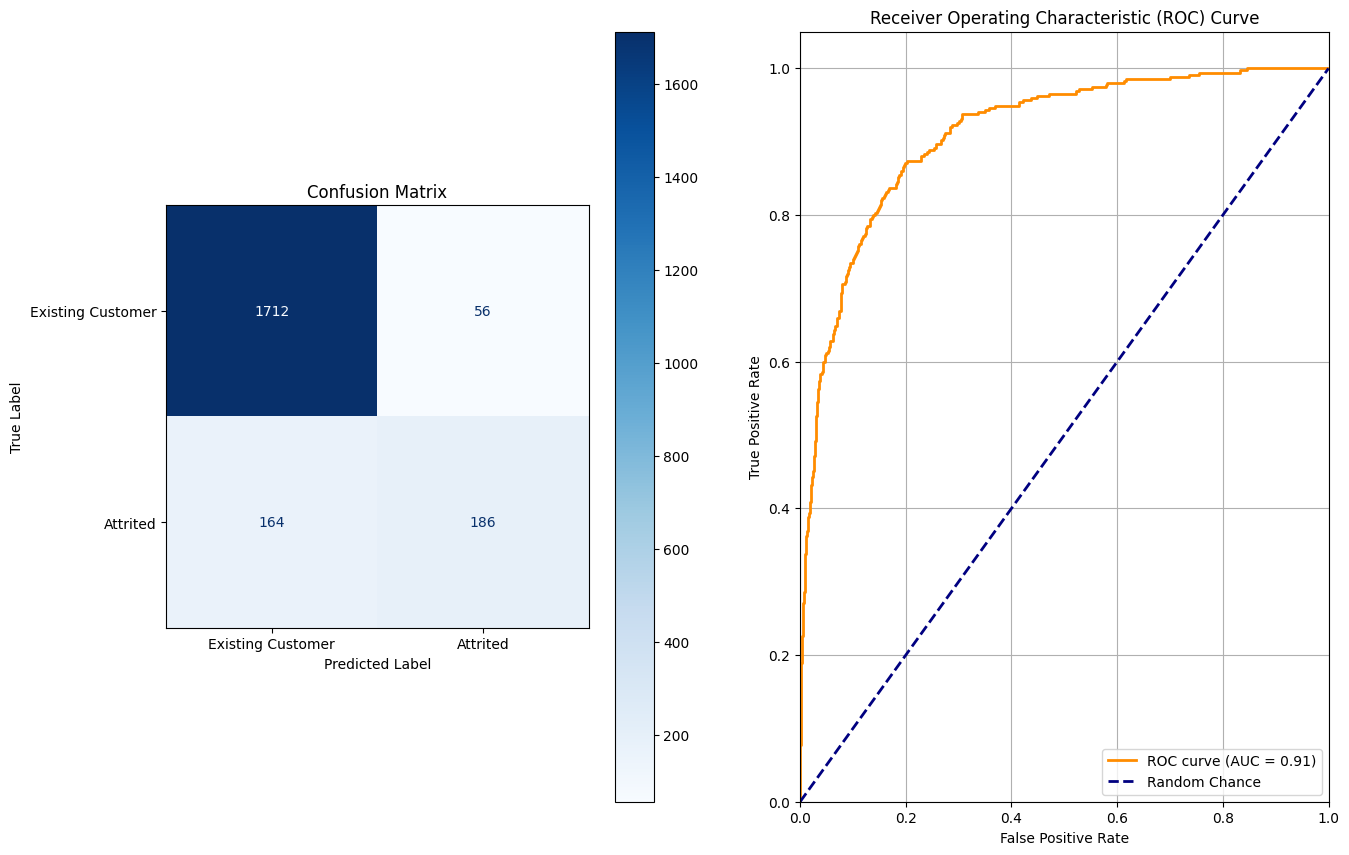



QDA RESULTS: 
Number of Attrited Predictions: 598
Number of Existing Customer Predictions: 1520
Percent Attrited Predictions: 28.234183191690278
Percent Existing Customer Predictions: 71.76581680830972

Accuracy: 0.8328611898016998


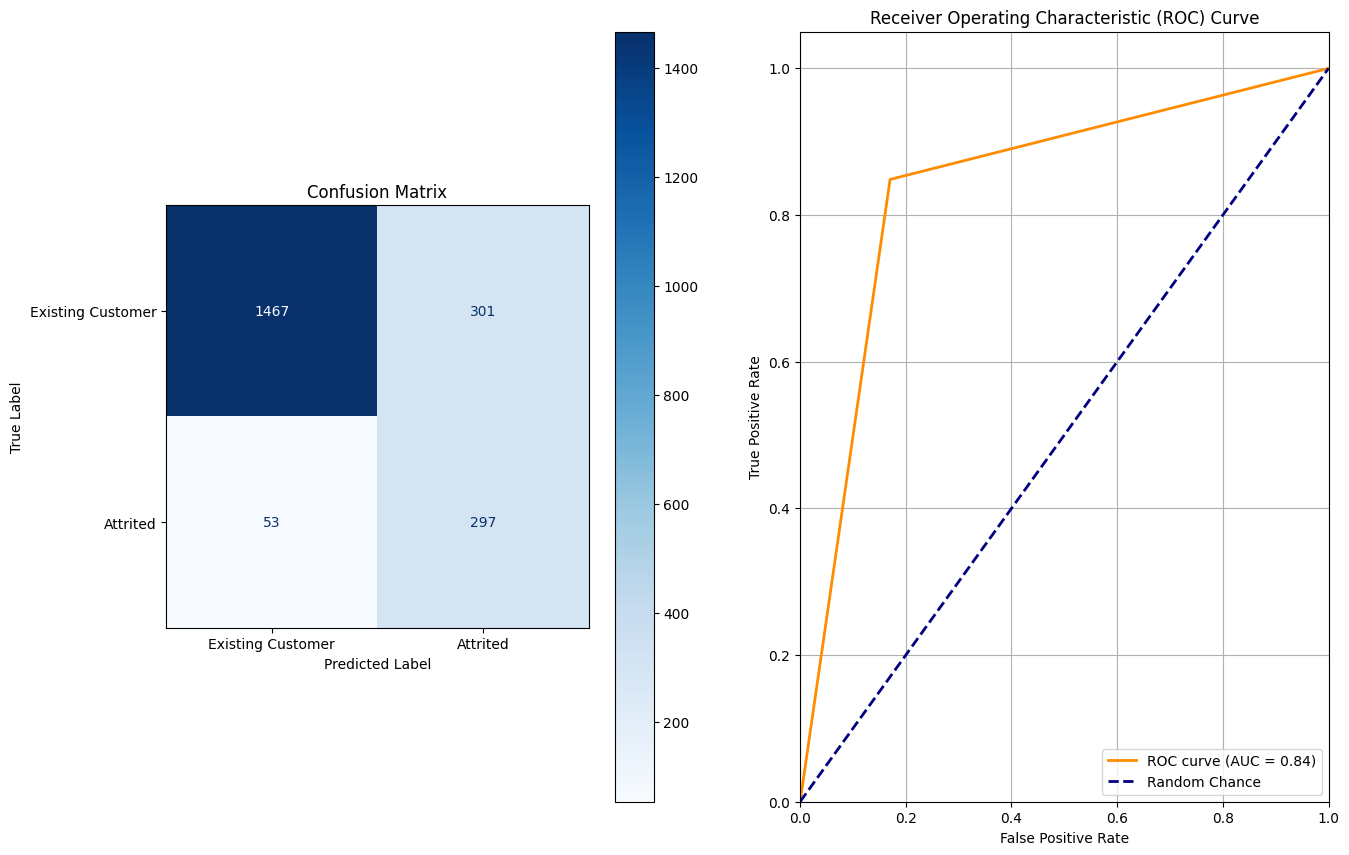



KNN RESULTS: 
Number of neighbors selected: 7
Number of Attrited Predictions: 282
Number of Existing Customer Predictions: 1836
Percent Attrited Predictions: 13.314447592067987
Percent Existing Customer Predictions: 86.68555240793201

Accuracy: 0.8838526912181303


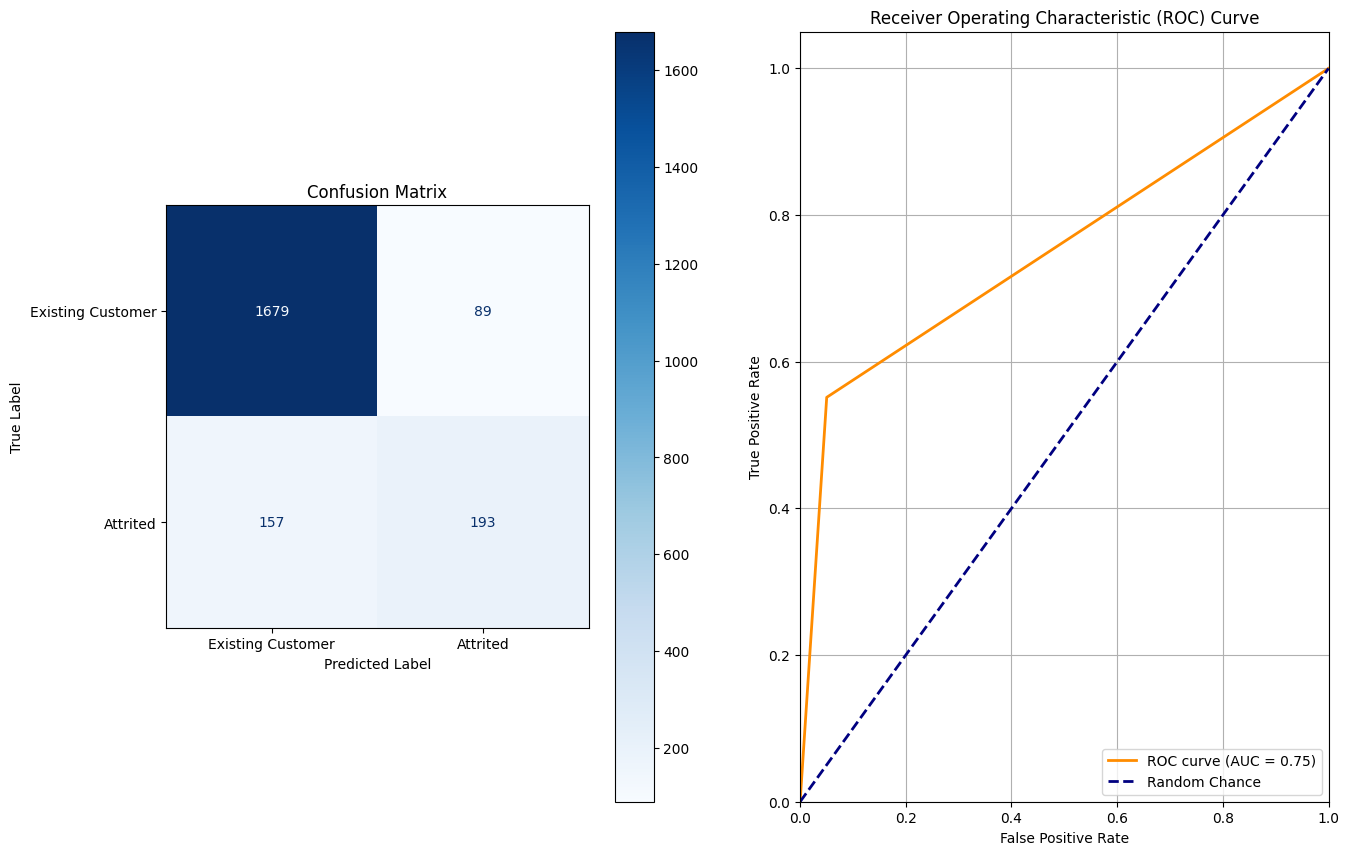

In [186]:
training_data, eval_data = split_data(null_model_data)

X = training_data.drop('Attrition_Flag', axis=1).values
y = training_data[['Attrition_Flag']]

novel_X = eval_data.drop('Attrition_Flag', axis=1).values
novel_y = eval_data[['Attrition_Flag']]

model_names = ['Logistic Regression', 'QDA', 'KNN']

labels = ['Existing Customer', 'Attrited']

model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)

### Additional Null Model Testing

For the sake of consistency in evaluating model improvement, correct the class imbalance in the null model data and re-fit each model.



Logistic Regression RESULTS: 
         Current function value: 0.168534
         Iterations: 35
Number of Attrited Predictions: 326
Number of Existing Customer Predictions: 656
Percent Attrited Predictions: 33.19755600814664
Percent Existing Customer Predictions: 66.80244399185335

Accuracy: 0.9236252545824847


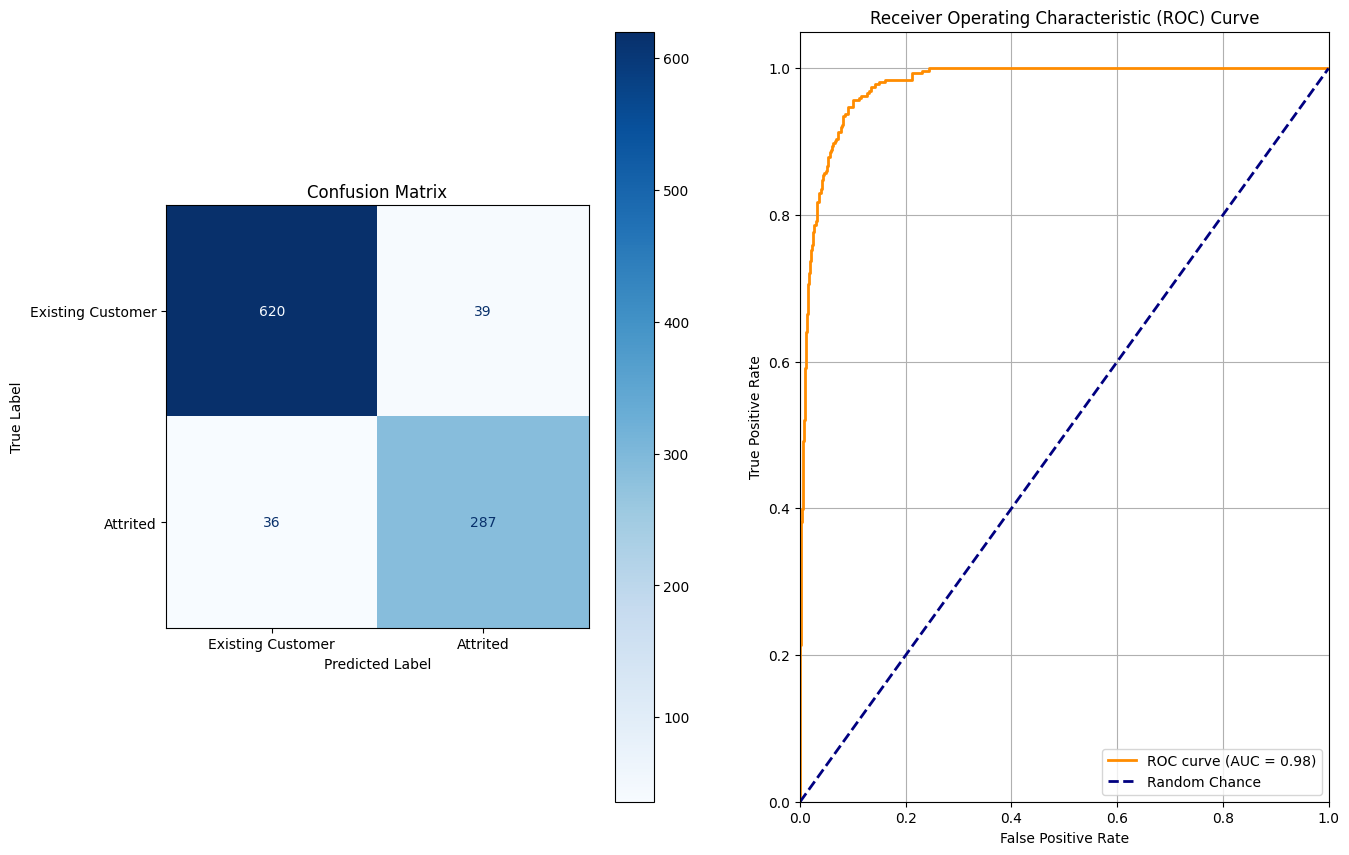



QDA RESULTS: 
Number of Attrited Predictions: 312
Number of Existing Customer Predictions: 670
Percent Attrited Predictions: 31.771894093686353
Percent Existing Customer Predictions: 68.22810590631364

Accuracy: 0.9276985743380856


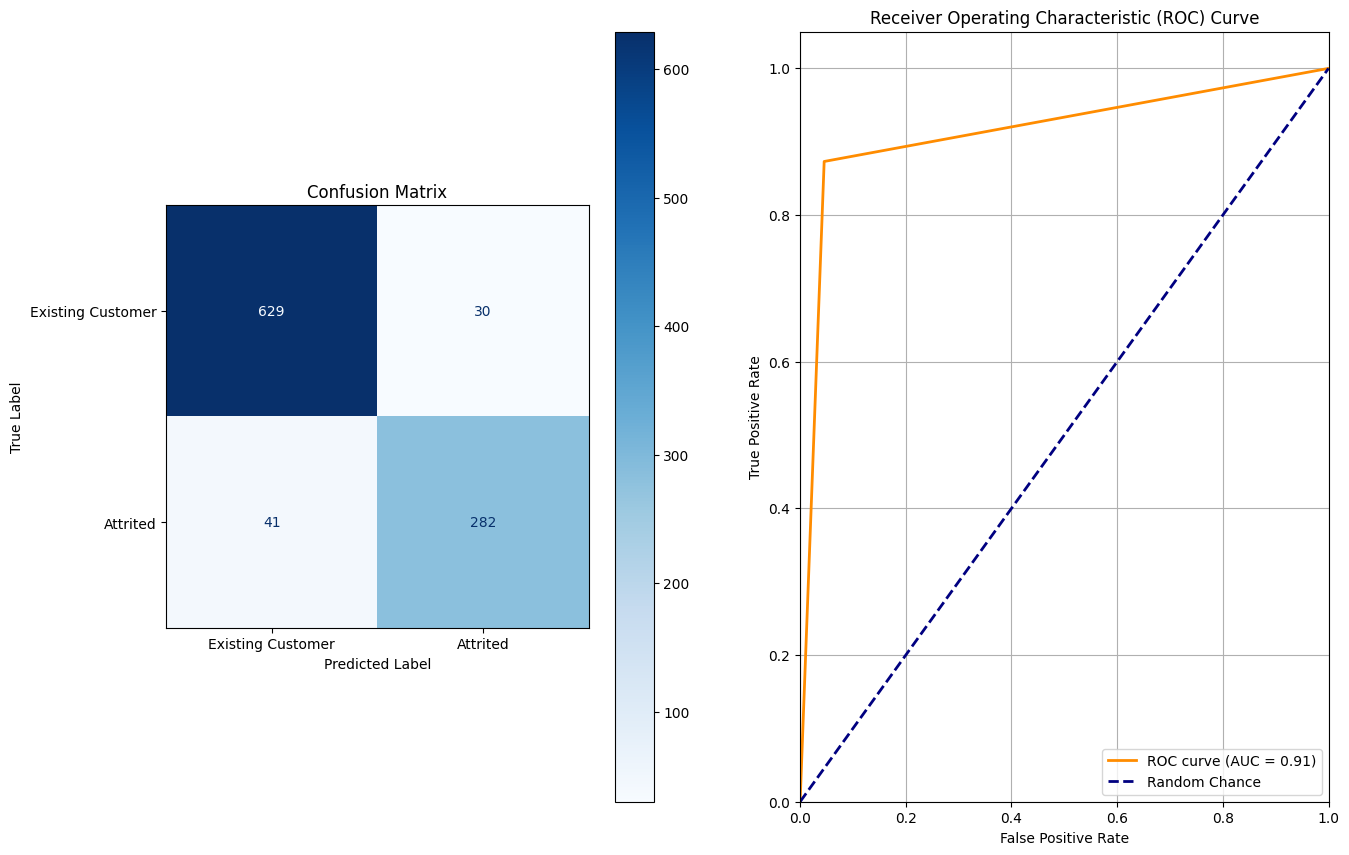



KNN RESULTS: 
Number of neighbors selected: 7
Number of Attrited Predictions: 305
Number of Existing Customer Predictions: 677
Percent Attrited Predictions: 31.05906313645621
Percent Existing Customer Predictions: 68.94093686354378

Accuracy: 0.9287169042769857


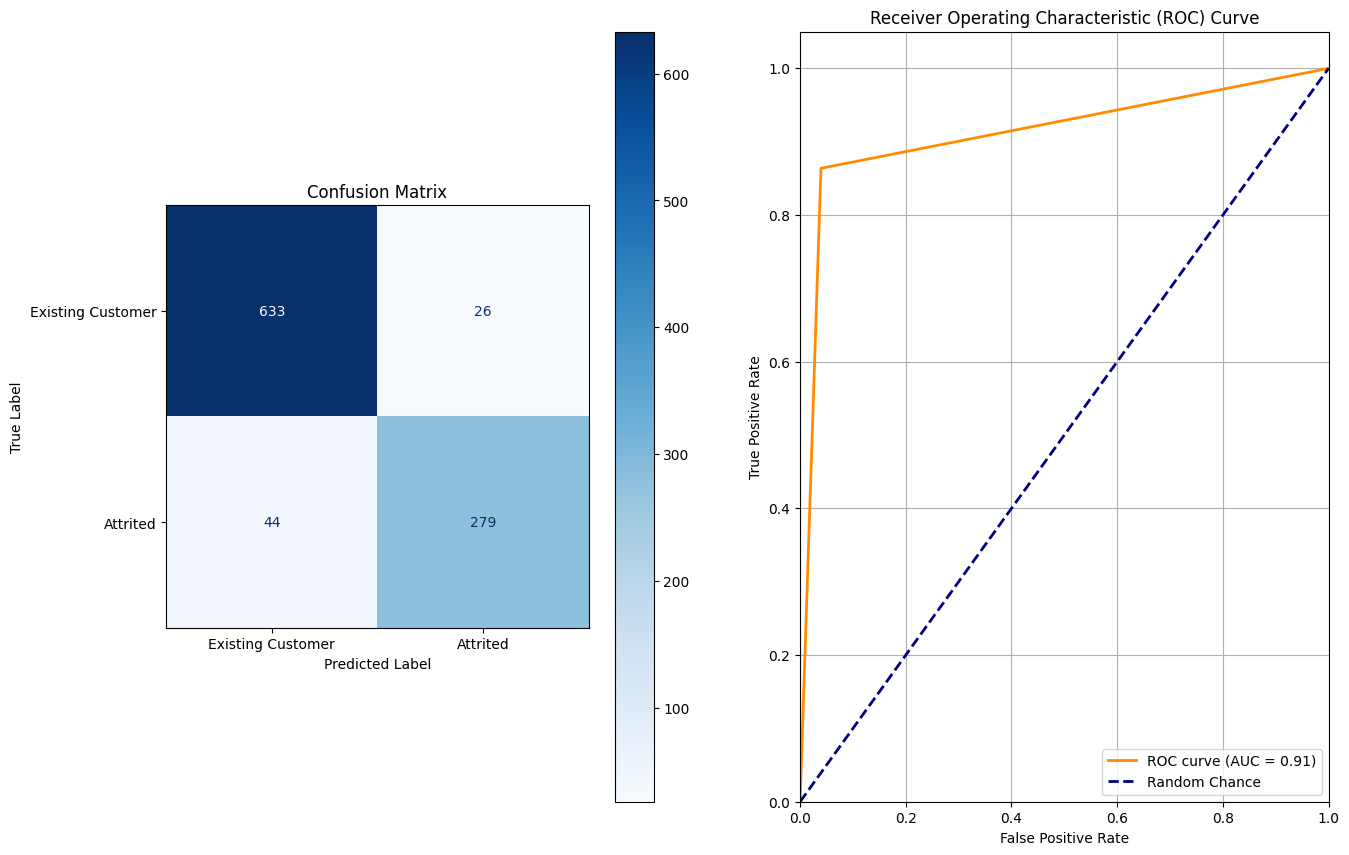

In [187]:
reduced_data = reduce_data(null_model_data, 65)

training_data, eval_data = split_data(reduced_data)

X = training_data.drop('Attrition_Flag', axis=1).values
y = training_data[['Attrition_Flag']]

novel_X = eval_data.drop('Attrition_Flag', axis=1).values
novel_y = eval_data[['Attrition_Flag']]

model_names = ['Logistic Regression', 'QDA', 'KNN']

labels = ['Existing Customer', 'Attrited']

model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)



Logistic Regression RESULTS: 
         Current function value: 0.178310
         Iterations: 35
Number of Attrited Predictions: 353
Number of Existing Customer Predictions: 441
Percent Attrited Predictions: 44.45843828715365
Percent Existing Customer Predictions: 55.541561712846345

Accuracy: 0.9181360201511335


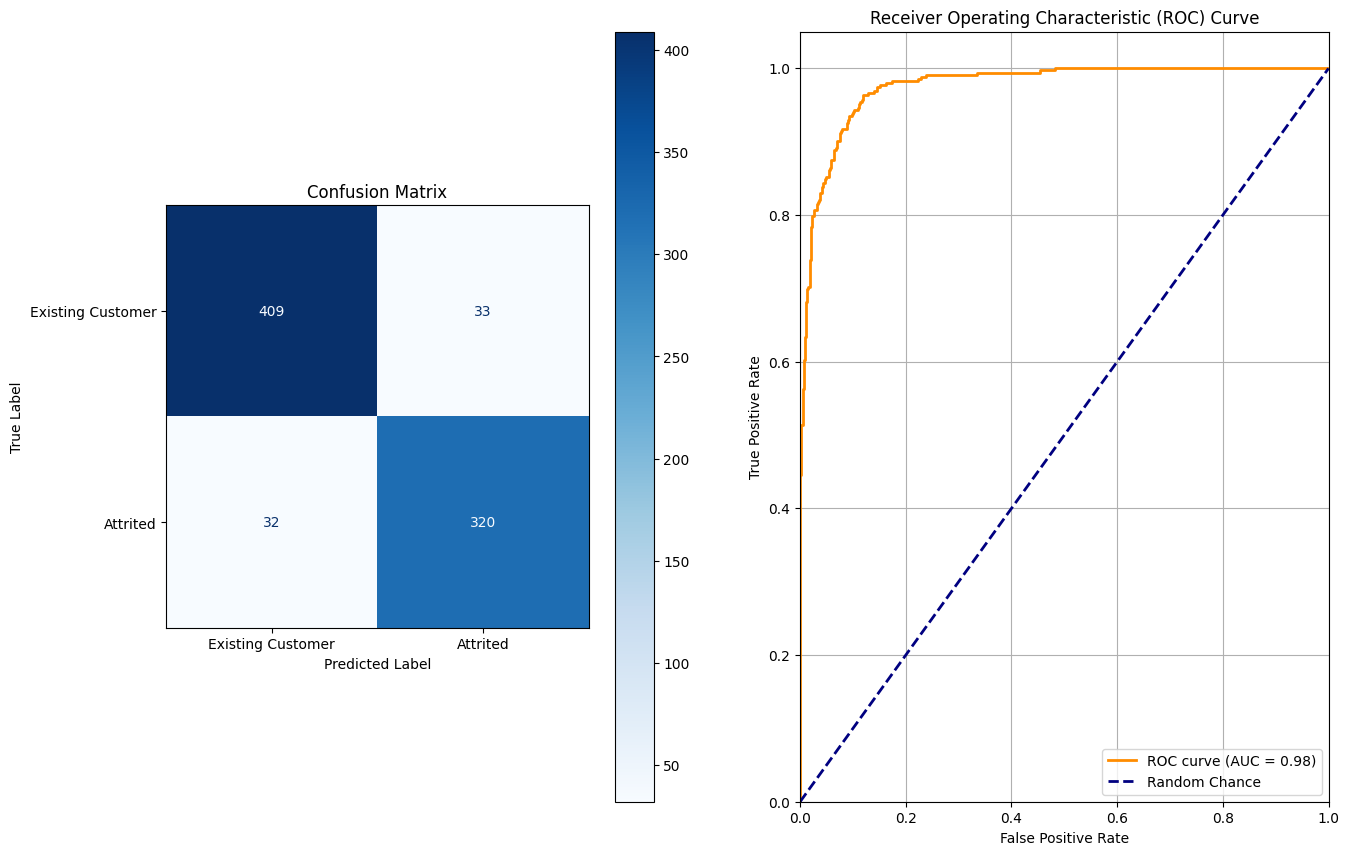



QDA RESULTS: 
Number of Attrited Predictions: 312
Number of Existing Customer Predictions: 482
Percent Attrited Predictions: 39.29471032745592
Percent Existing Customer Predictions: 60.70528967254408

Accuracy: 0.9219143576826196


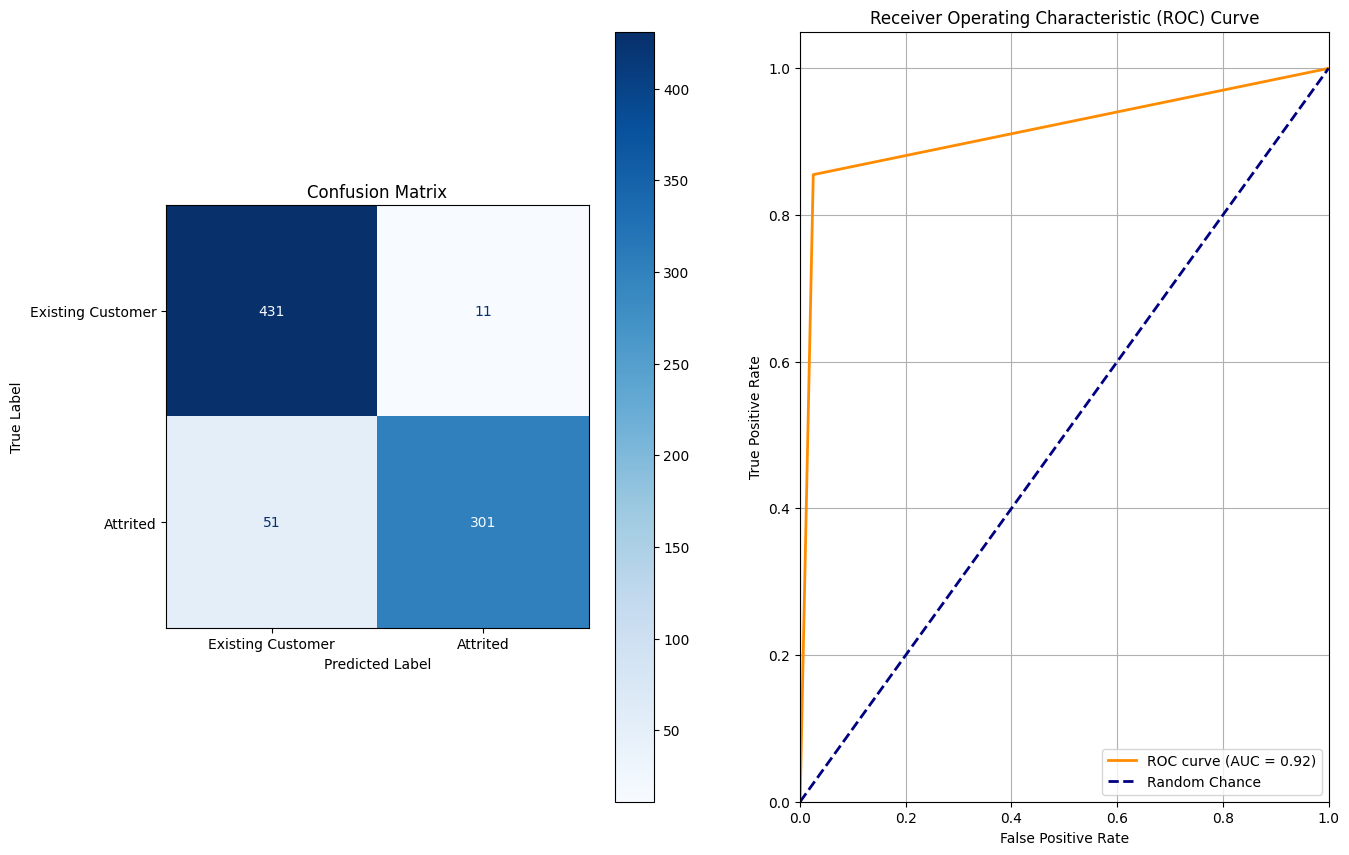



KNN RESULTS: 
Number of neighbors selected: 7
Number of Attrited Predictions: 344
Number of Existing Customer Predictions: 450
Percent Attrited Predictions: 43.32493702770781
Percent Existing Customer Predictions: 56.67506297229219

Accuracy: 0.9395465994962217


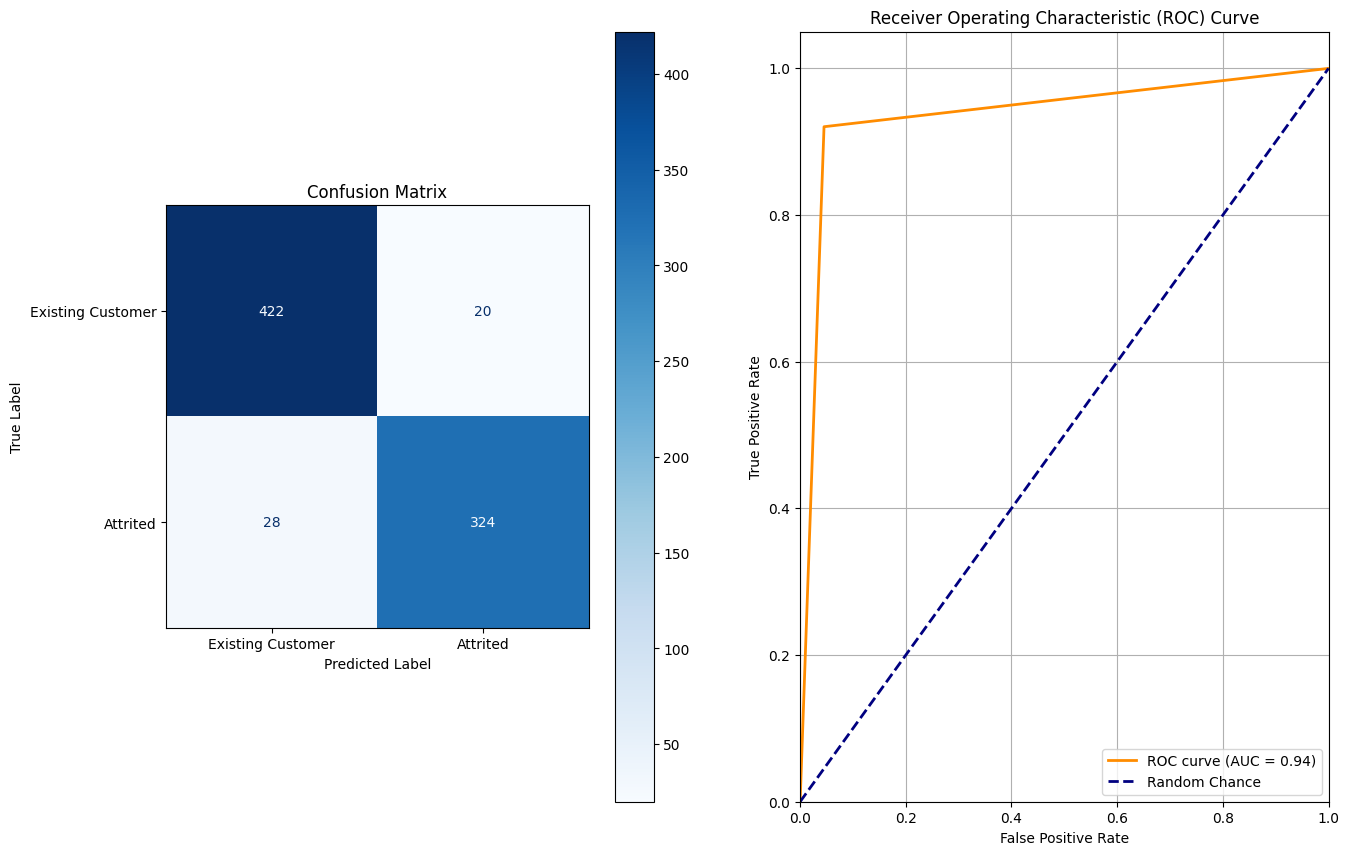

In [188]:
reduced_data = reduce_data(null_model_data, 75)

training_data, eval_data = split_data(reduced_data)

X = training_data.drop('Attrition_Flag', axis=1).values
y = training_data[['Attrition_Flag']]

novel_X = eval_data.drop('Attrition_Flag', axis=1).values
novel_y = eval_data[['Attrition_Flag']]

model_names = ['Logistic Regression', 'QDA', 'KNN']

labels = ['Existing Customer', 'Attrited']

model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)

## Models with Feature Engineering, Variable Selection, and Class Imbalance Compensation



Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.272782
         Iterations 7
Number of Attrited Predictions: 177
Number of Existing Customer Predictions: 1941
Percent Attrited Predictions: 8.356940509915015
Percent Existing Customer Predictions: 91.643059490085

Accuracy: 0.8777148253068933


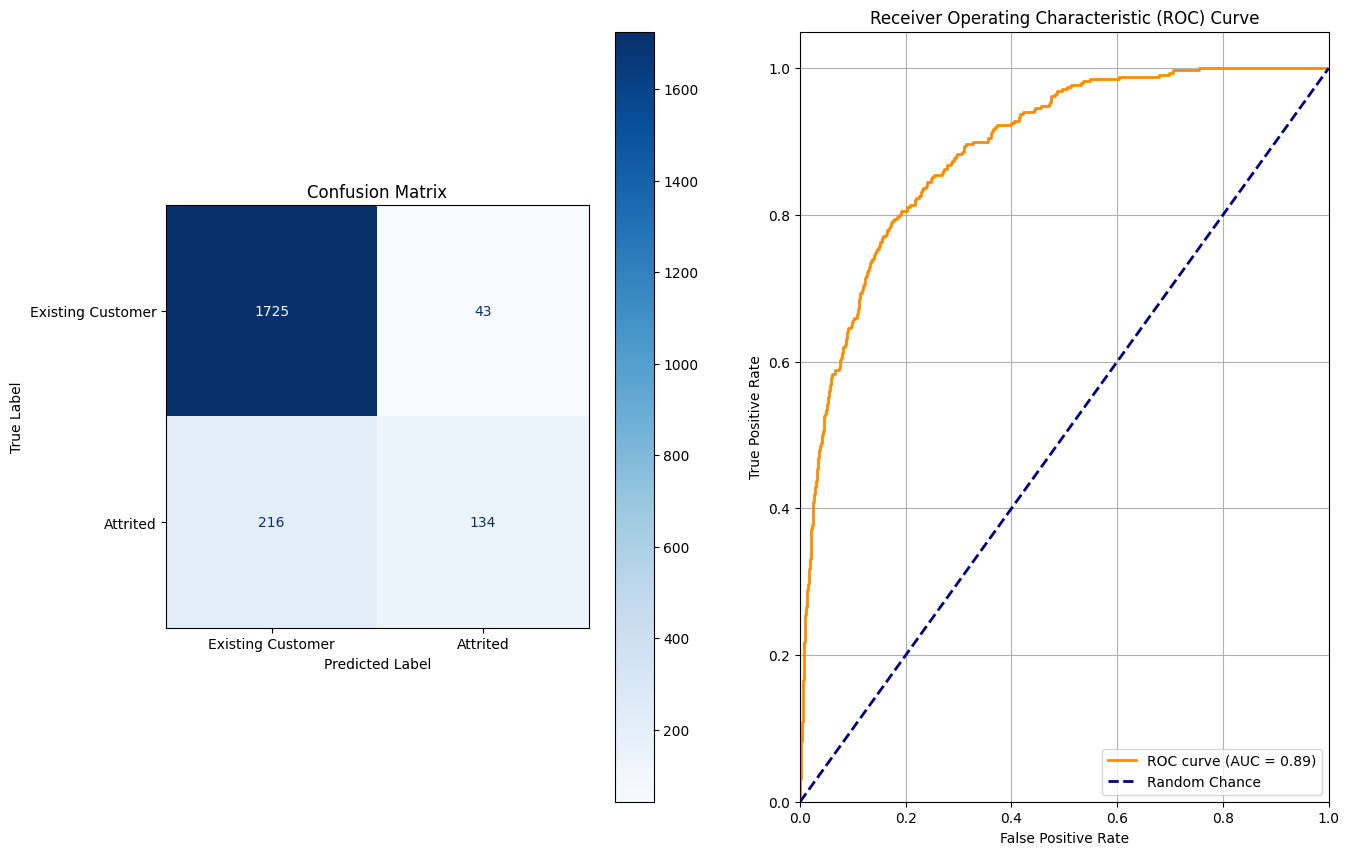



QDA RESULTS: 
Number of Attrited Predictions: 436
Number of Existing Customer Predictions: 1682
Percent Attrited Predictions: 20.585457979225687
Percent Existing Customer Predictions: 79.41454202077432

Accuracy: 0.8762983947119924


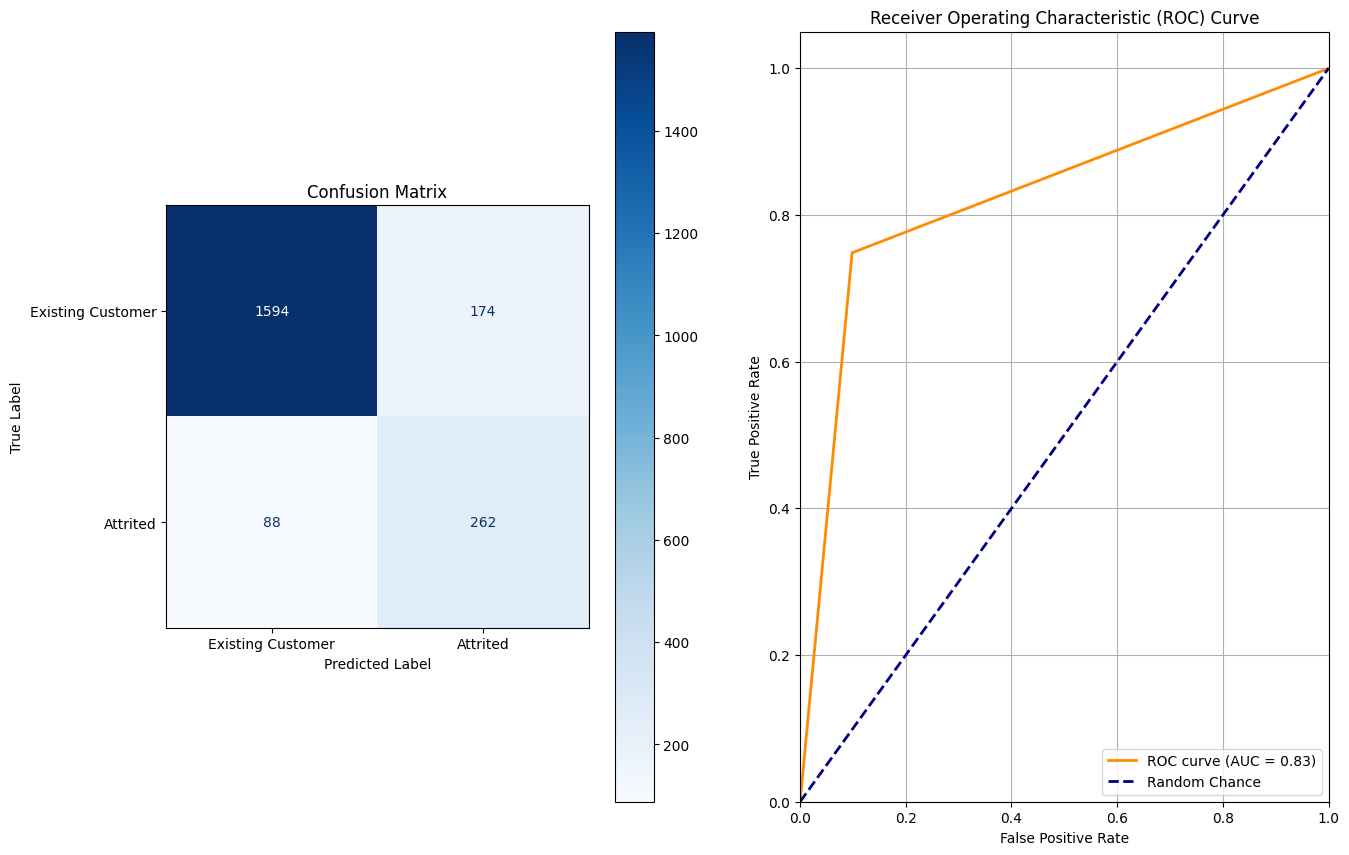



KNN RESULTS: 
Number of neighbors selected: 7
Number of Attrited Predictions: 286
Number of Existing Customer Predictions: 1832
Percent Attrited Predictions: 13.503305004721437
Percent Existing Customer Predictions: 86.49669499527857

Accuracy: 0.8999055712936733


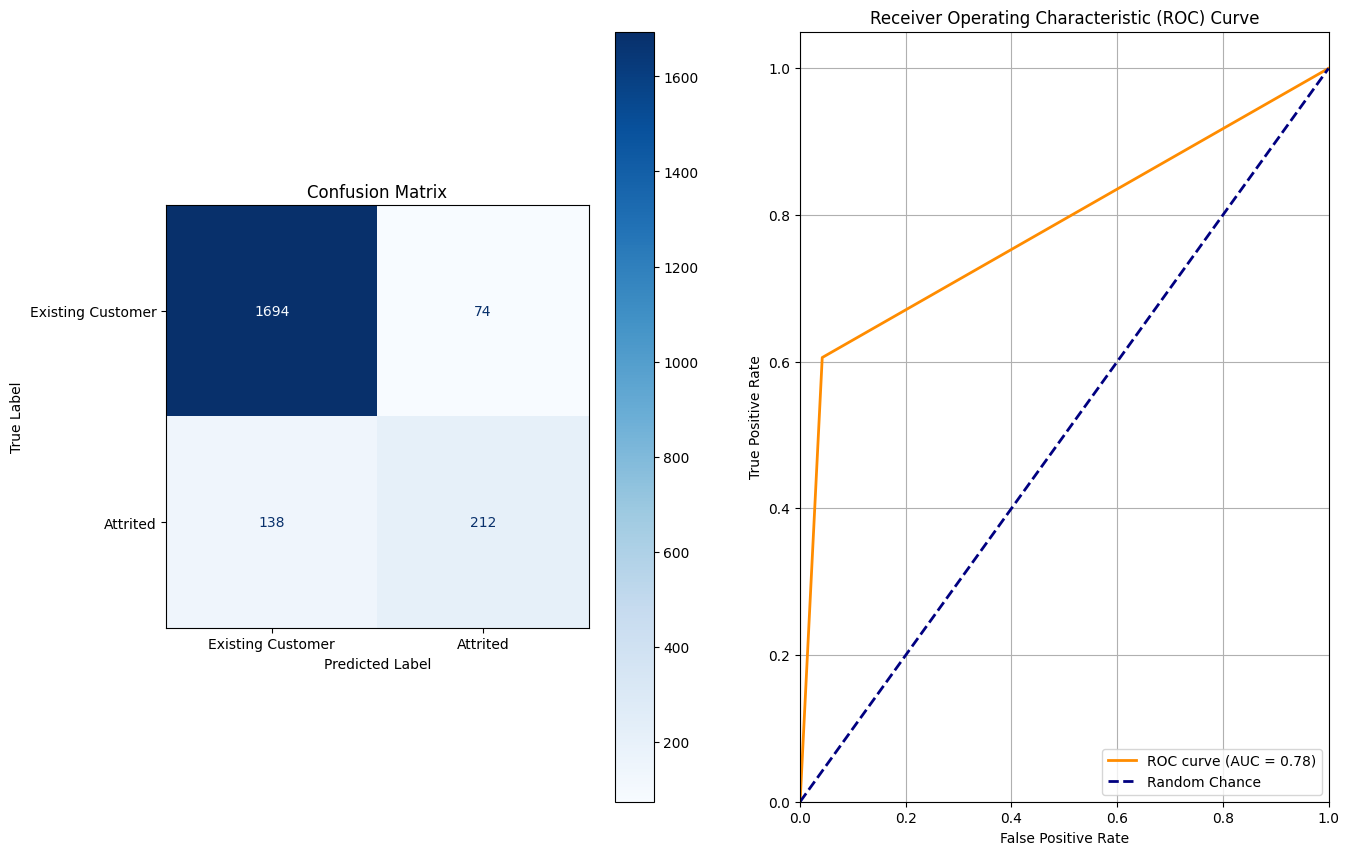

In [189]:
training_data, eval_data = split_data(data)

X = training_data.drop('Attrition_Flag', axis=1).values
y = training_data[['Attrition_Flag']]

novel_X = eval_data.drop('Attrition_Flag', axis=1).values
novel_y = eval_data[['Attrition_Flag']]

model_names = ['Logistic Regression', 'QDA', 'KNN']

labels = ['Existing Customer', 'Attrited']

model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)

## Initial Findings

All of the models performed well, but I suspect this is from class imbalance. The next step would be to mitigate this as a possible source of error.



Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.172334
         Iterations 9
Number of Attrited Predictions: 309
Number of Existing Customer Predictions: 673
Percent Attrited Predictions: 31.466395112016293
Percent Existing Customer Predictions: 68.5336048879837

Accuracy: 0.924643584521385


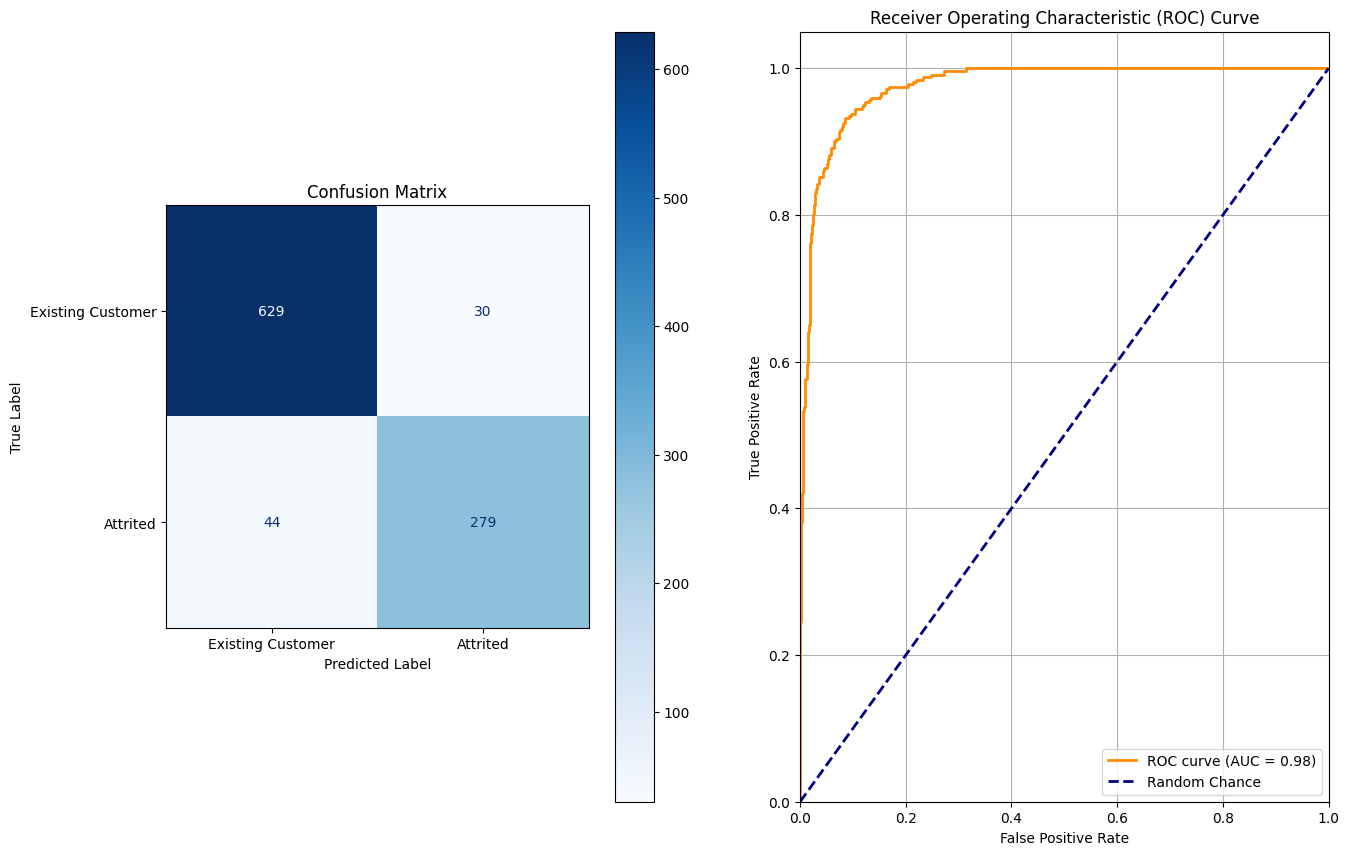



QDA RESULTS: 
Number of Attrited Predictions: 375
Number of Existing Customer Predictions: 607
Percent Attrited Predictions: 38.187372708757636
Percent Existing Customer Predictions: 61.812627291242364

Accuracy: 0.9083503054989817


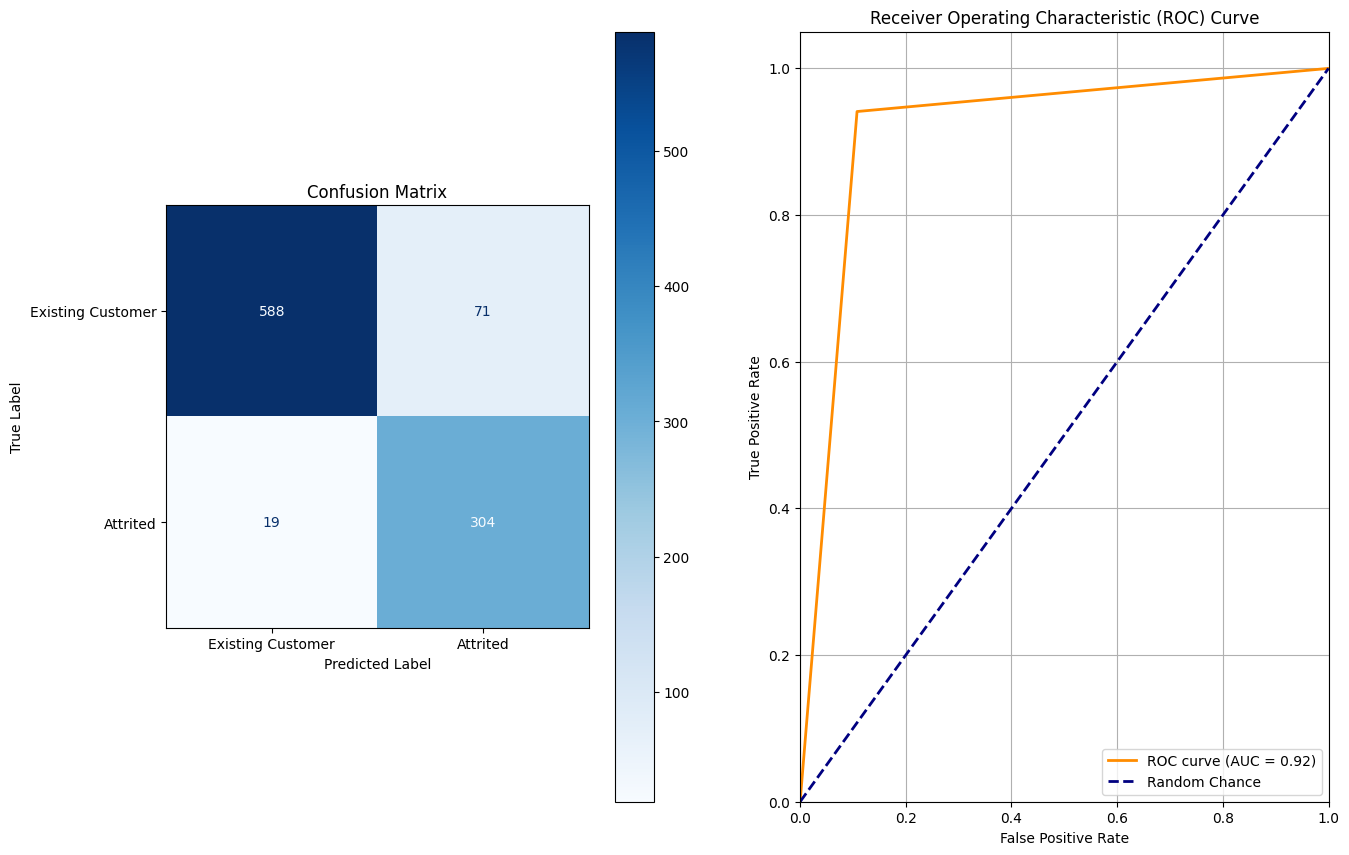



KNN RESULTS: 
Number of neighbors selected: 7
Number of Attrited Predictions: 326
Number of Existing Customer Predictions: 656
Percent Attrited Predictions: 33.19755600814664
Percent Existing Customer Predictions: 66.80244399185335

Accuracy: 0.9663951120162932


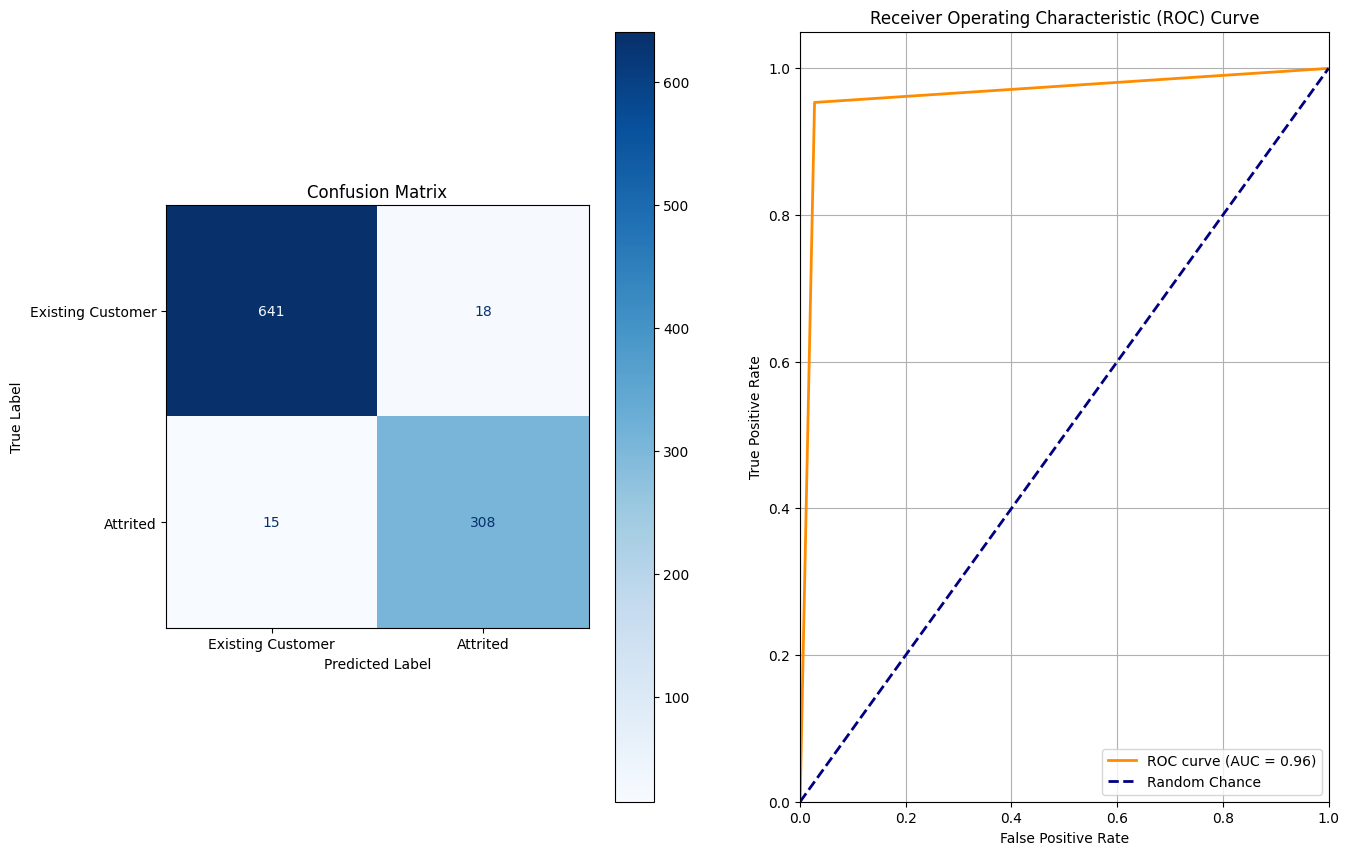

In [190]:
reduced_data = reduce_data(data, 65)

training_data, eval_data = split_data(reduced_data)

X = training_data.drop('Attrition_Flag', axis=1).values
y = training_data[['Attrition_Flag']]

novel_X = eval_data.drop('Attrition_Flag', axis=1).values
novel_y = eval_data[['Attrition_Flag']]

model_names = ['Logistic Regression', 'QDA', 'KNN']

labels = ['Existing Customer', 'Attrited']

model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)



Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.185162
         Iterations 9
Number of Attrited Predictions: 341
Number of Existing Customer Predictions: 453
Percent Attrited Predictions: 42.9471032745592
Percent Existing Customer Predictions: 57.0528967254408

Accuracy: 0.9156171284634761


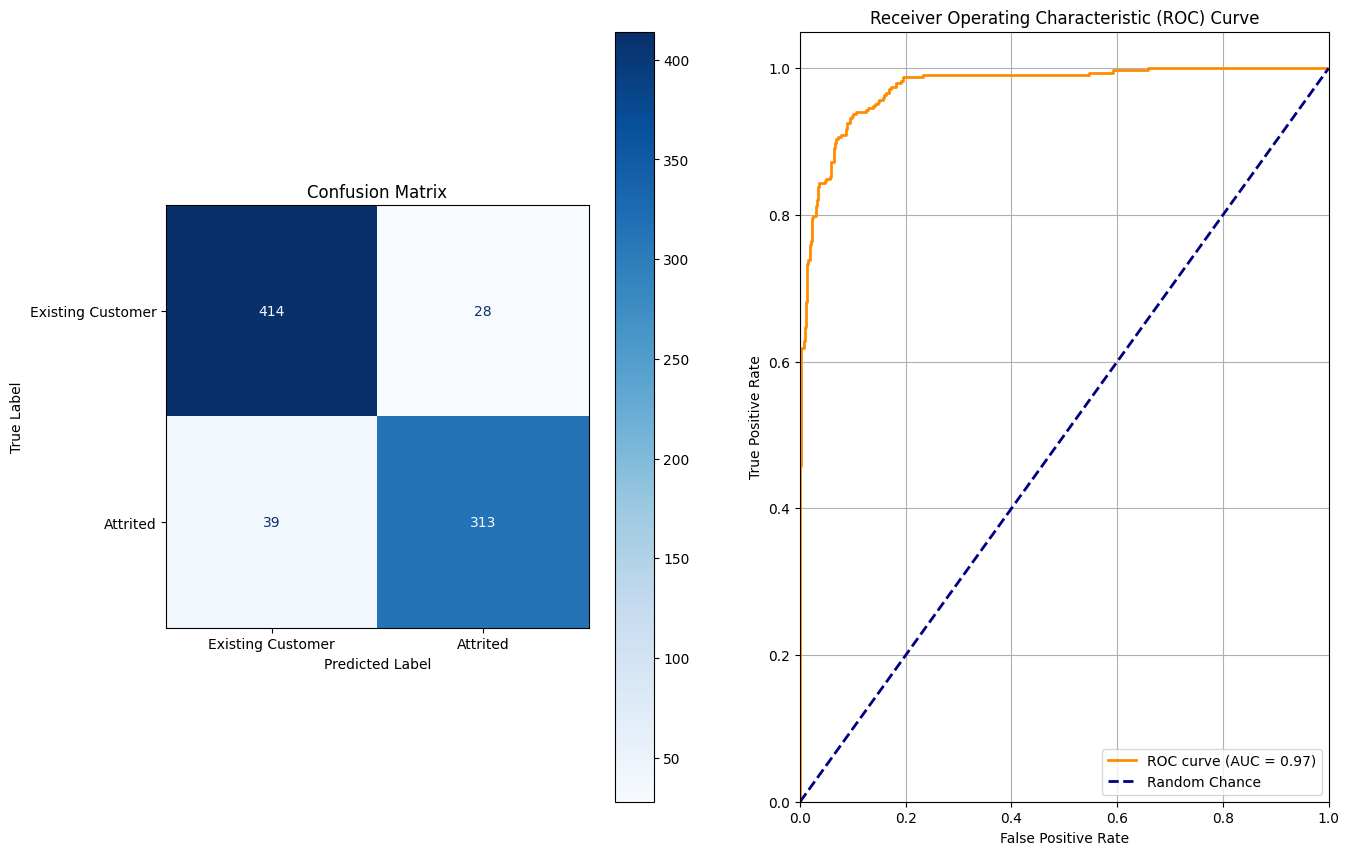



QDA RESULTS: 
Number of Attrited Predictions: 387
Number of Existing Customer Predictions: 407
Percent Attrited Predictions: 48.740554156171285
Percent Existing Customer Predictions: 51.25944584382871

Accuracy: 0.9156171284634761


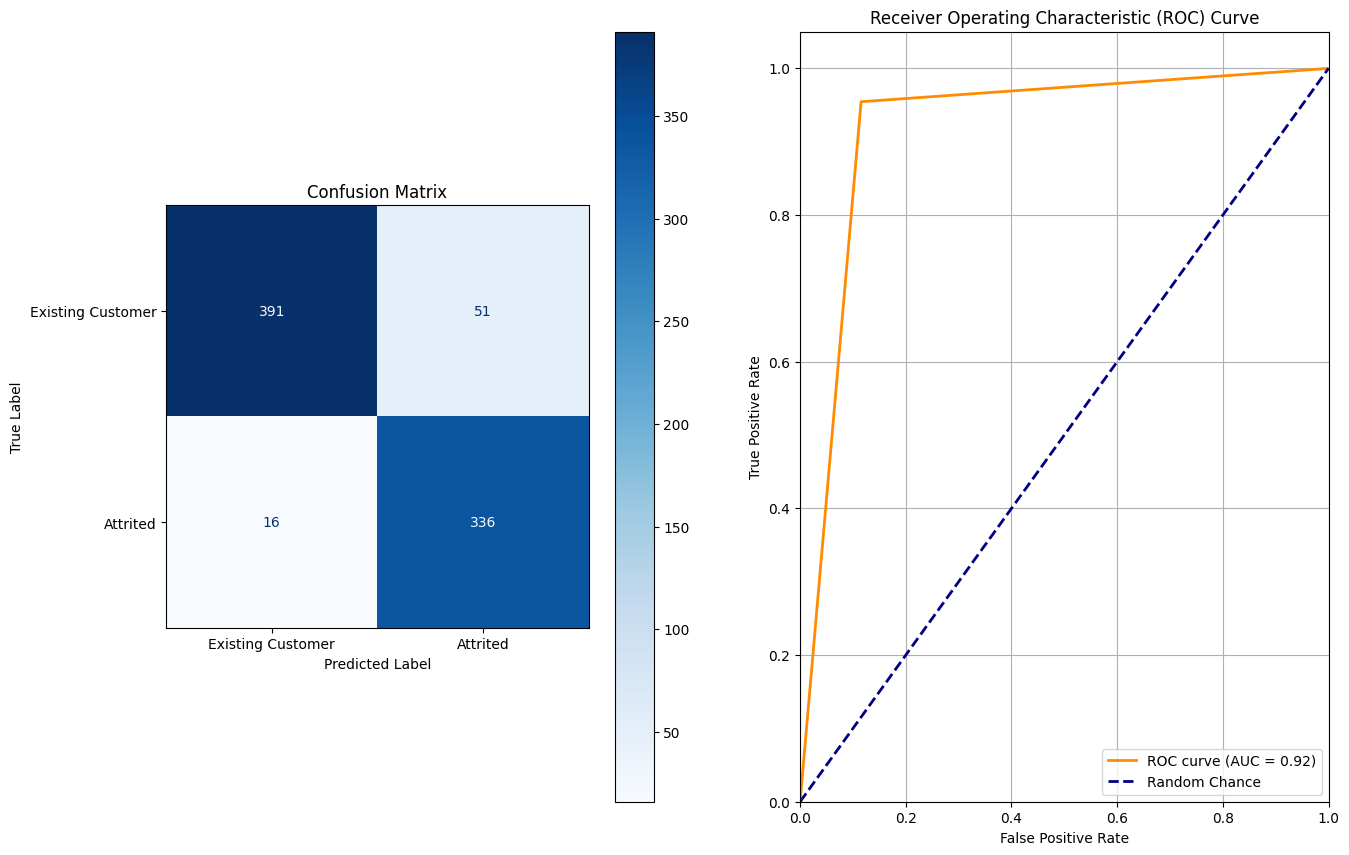



KNN RESULTS: 
Number of neighbors selected: 7
Number of Attrited Predictions: 349
Number of Existing Customer Predictions: 445
Percent Attrited Predictions: 43.95465994962217
Percent Existing Customer Predictions: 56.04534005037783

Accuracy: 0.9609571788413098


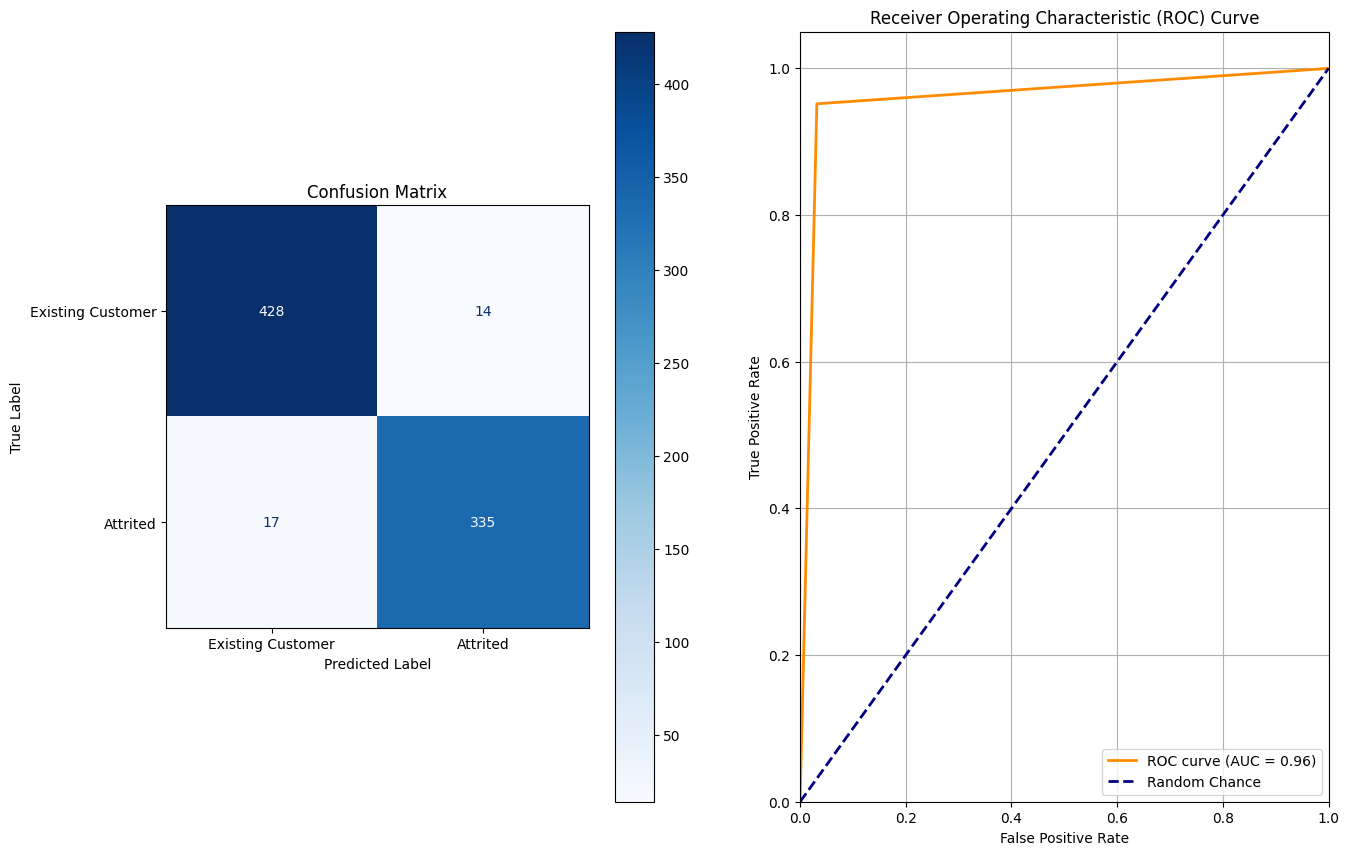

In [191]:
reduced_data = reduce_data(data, 75)

training_data, eval_data = split_data(reduced_data)

X = training_data.drop('Attrition_Flag', axis=1).values
y = training_data[['Attrition_Flag']]

novel_X = eval_data.drop('Attrition_Flag', axis=1).values
novel_y = eval_data[['Attrition_Flag']]

model_names = ['Logistic Regression', 'QDA', 'KNN']

labels = ['Existing Customer', 'Attrited']

model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)